In [3]:
library(tidyverse)
library(ggplot2)
library(readr)
library(stringr)
library(colorBlindness)
library(Statial)
library(rstatix)
library(ComplexHeatmap)
library(circlize)
library(spatstat.geom)
library(spatstat.model)
library(jsonlite)
library(reticulate)
library(data.table)
library(scales)
library(data.table)

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘rstatix’


The following object is masked from ‘pa

In [4]:
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"

In [5]:
celltype_metadata <- readr::read_csv(
  paste0(results_dir, "/celltype_metadata_final.csv")
)

Rows: 578608 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): cell_type, cell_category, patient_ID, exp_name, patient_exp, sample...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months
lgl (1): is_sample_primary

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells") ~ "Myeloid",
      cell_category %in% c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs") ~ "Lymphoid",
      cell_category %in% c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells") ~ "Non-immune",
      cell_category %in% c("NFC") ~ "NFC",
      cell_category %in% c("Tumor cells") ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

In [5]:
patient_levels <- celltype_metadata %>%
  mutate(
    patient_ID  = str_replace(patient_ID, "^NMC_", "NUT_"),
    patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
  ) %>%
  distinct(patient_ID, patient_num) %>%
  arrange(desc(patient_num)) %>%   # or arrange(patient_num) if you want ascending
  pull(patient_ID)

In [563]:
celltype_metadata$cell_category_simplified %>% unique()
celltype_metadata$patient_ID %>% unique()

[1] Myeloid    NFC        Tumor      Non-immune Lymphoid  
Levels: Non-immune Lymphoid Myeloid NFC Tumor

[1] "NMC_1"  "NMC_2"  "NMC_4"  "NMC_5"  "NMC_6"  "NMC_7"  "NMC_8"  "NMC_9" 
 [9] "NMC_12" "NMC_13" "NMC_14" "NMC_15" "NMC_16" "NMC_21"

In [564]:
#get percentages of cell types per patient
cellgroup_percentage_patient = celltype_metadata %>%
  group_by(patient_ID, cell_category_simplified) %>%
  summarise(n = n()) %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100,
  patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
   ) %>%
   ungroup() %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_")) %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) %>%
  select(-patient_num)

`summarise()` has grouped output by 'patient_ID'. You can override using the
`.groups` argument.


In [565]:
#get percentages of cell types per patient
myeloid_percentage_patient = celltype_metadata %>%
  filter(cell_category_simplified == "Myeloid") %>%
  group_by(patient_ID, cell_category) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100,
  patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
   ) %>%
   ungroup() %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_")) %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) %>%
  select(-patient_num)

In [567]:
#get percentages of cell types per patient
myeloid_percentage_patient = celltype_metadata %>%
  group_by(patient_ID, cell_category, cell_category_simplified) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100,
  patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
   ) %>%
   ungroup() %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_")) %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) %>%
  select(-patient_num) %>%
filter(cell_category_simplified == "Myeloid")


In [276]:
#get percentages of cell types per patient
lymphoid_percentage_patient = celltype_metadata %>%
  filter(cell_category_simplified == "Lymphoid") %>%
  group_by(patient_ID, cell_category) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100,
  patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
   ) %>%
   ungroup() %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_")) %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) %>%
  select(-patient_num) %>%
  mutate(cell_category = factor(cell_category, levels = c(
  "PCs", "B cells",
  "NK cells",
  "Treg T cells",
  "CD4+ T cells",
  "CD8+ T cells"
)))

In [328]:
#get percentages of cell types per patient
lymphoid_percentage_patient = celltype_metadata %>%
  group_by(patient_ID, cell_category, cell_category_simplified) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100,
  patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
   ) %>%
   ungroup() %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_")) %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) %>%
  select(-patient_num) %>%
  mutate(cell_category = factor(cell_category, levels = c(
  "PCs", "B cells",
  "NK cells",
  "Treg T cells",
  "CD4+ T cells",
  "CD8+ T cells"
))) %>%
filter(cell_category_simplified == "Lymphoid")


In [331]:
#get percentages of cell types per patient
nonimmune_percentage_patient = celltype_metadata %>%
  group_by(patient_ID, cell_category, cell_category_simplified) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100,
  patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
   ) %>%
   ungroup() %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_")) %>%
  mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID))) %>%
  select(-patient_num) %>%
filter(cell_category_simplified == "Non-immune")

In [143]:
full_palette_updated <- c(
  # ---- Lymphoid ----
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#7F1D1D",
  "NK cells" = "#6E8B8F",
  "B cells" = "#F0D34F",
  "PCs" = "#B88A00",

  # ---- Myeloid ----
  "M1 macrophages" = "#E16A2E",
  "M2 macrophages" = "#6F8F1A",
  "M1/M2 macrophages" = "#F6AE2D",
  "DCs" = "#D4A72C",
  "Granulocytes" = "#7B61B3",
  "MDSCs" = "#0077A8",
  "Mast cells" = "#5A3B2E",

  # ---- Tumor / other ----
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD",

  # ---- Non-immune ----
  "Actin+ cells" = "#C77C9B",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#C9B29B"
)


In [641]:
main_group_colors <- c(
  "Tumor"      = "#44AA99",
  "Lymphoid"   = "#B2182B",
  "Myeloid"    = "#332288",
  "Non-immune" = "#C9B29B",
  "NFC"        = "#DDDDDD"
)


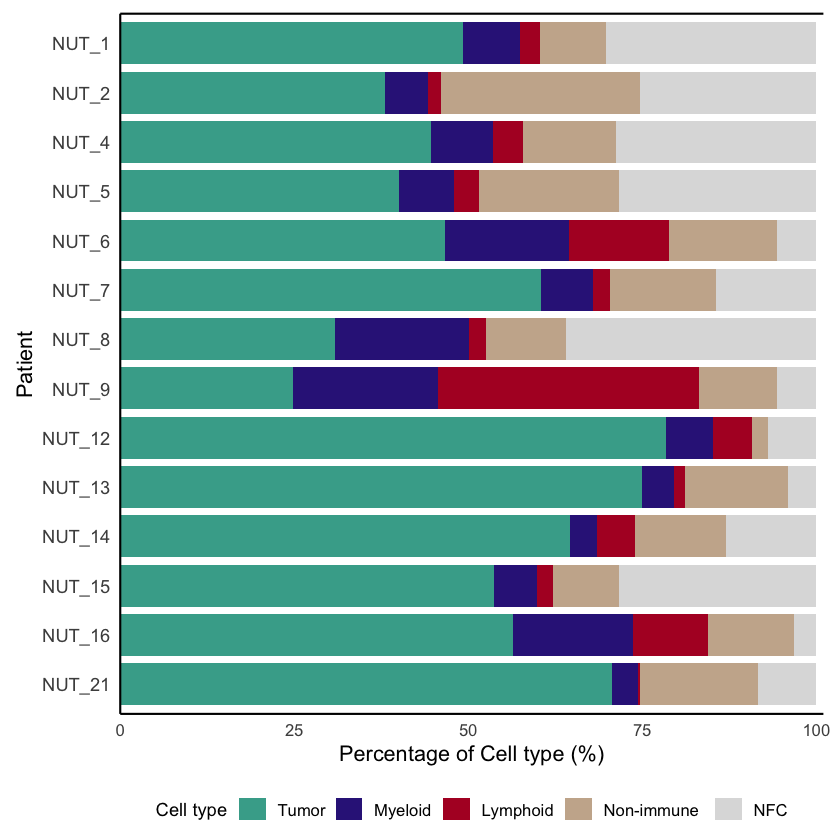

In [688]:
shared_margin <- margin(t = 5, r = 10, b = 5, l = 10)
p_main = ggplot(
  celltype_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category_simplified)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = main_group_colors) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of Cell type (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )
p_main
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/celltype_composition_by_subgroups.svg",
  plot = p_main,
  width = 7,
  height = 7,
  dpi = 300
)

In [706]:
myeloid_palette <- c(
  "MDSCs"             = "#332288",
  "M2 macrophages"    = "#66A61E",  # lighter olive (not teal)
  "M1 macrophages"    = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs"               = "#E69F00",
  "Granulocytes"      = "#B85AA6",
  "Mast cells"        = "#8E006A"
)

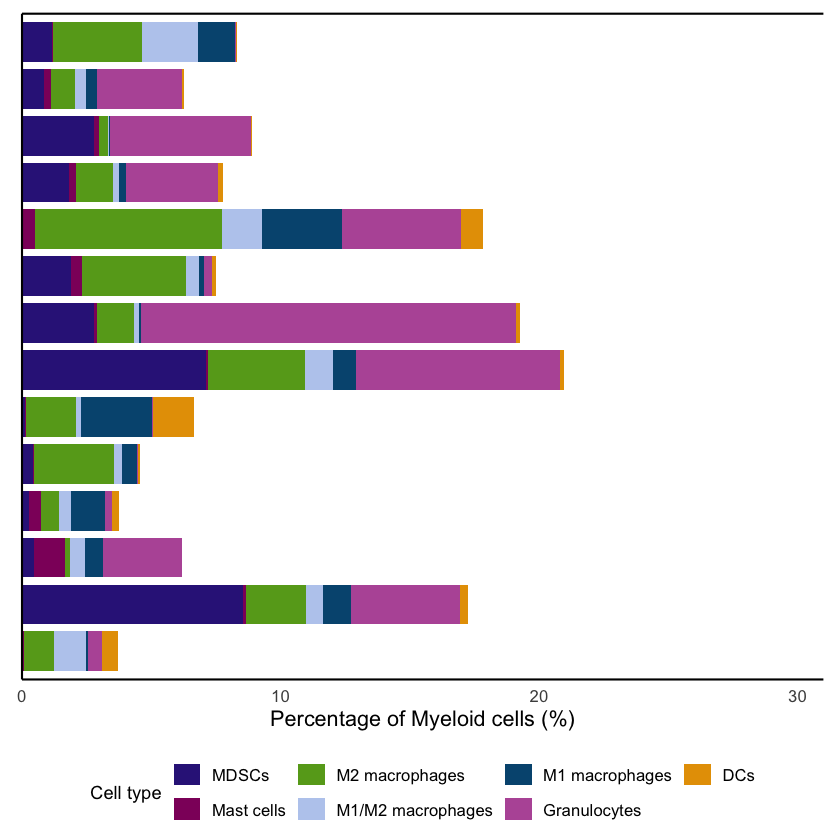

In [707]:
shared_margin <- margin(t = 5, r = 10, b = 5, l = 10)
p_myeloid = ggplot(
  myeloid_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = myeloid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of Myeloid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )
p_myeloid
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/celltype_composition_by_myeloids.svg",
  plot = p_myeloid,
  width = 7,
  height = 7,
  dpi = 300
)

In [708]:
lymphoid_palette <- c(
  "CD8+ T cells"  = "#B2182B",  # deep red
  "CD4+ T cells"  = "#EF8A62",  # salmon
  "Treg T cells"  = "#FFCCCC",  # dark muted red (still clearly “T”)
  "NK cells"      = "#0096FF", # olive green
  "B cells"       = "#E6C84F" ,  # muted golden yellow
  "PCs"           =  "#F4E58A"# lighter, creamy yellow
)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


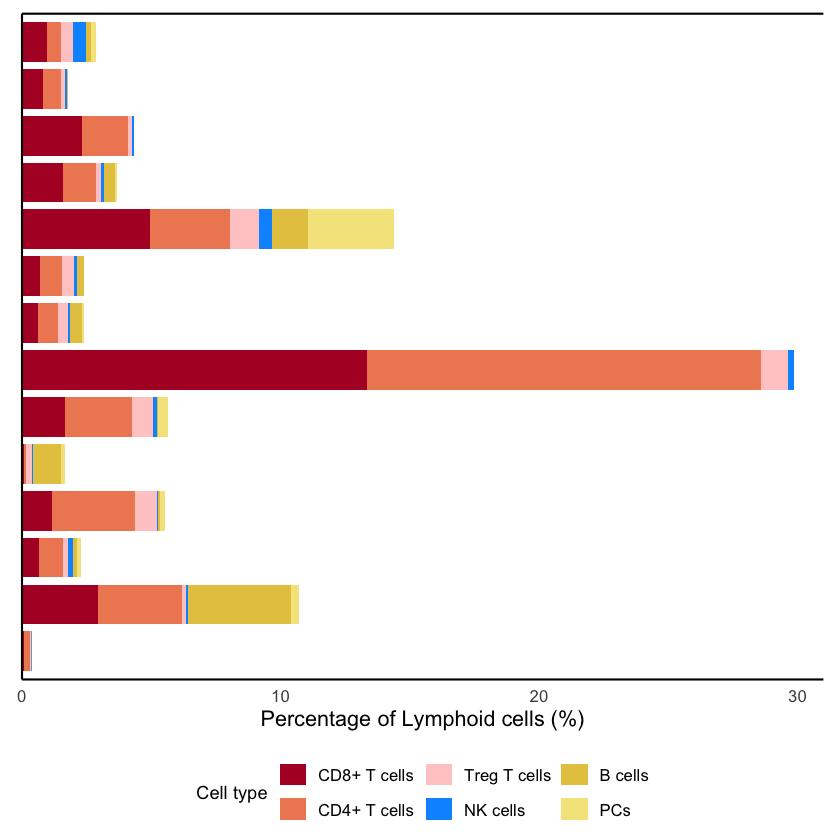

In [709]:
shared_margin <- margin(t = 5, r = 10, b = 5, l = 10)
p_lymphoid = ggplot(
  lymphoid_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = lymphoid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of Lymphoid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )
p_lymphoid
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/celltype_composition_by_lymphocytes.svg",
  plot = p_lymphoid,
  width = 7,
  height = 7,
  dpi = 300
)

In [711]:
non_immune_palette <- c(
  "Actin+ cells" = "#C77C9B",                # dusty mauve-pink (anchor)
  "Endothelial cells" = "#7F8F6A",           # muted olive-sage (NOT teal)
  "Lymphatic endothelial cells" = "#A6B08A", # lighter sage-olive
  "Epithelial cells" = "#C9B29B"              # warm taupe / beige
)


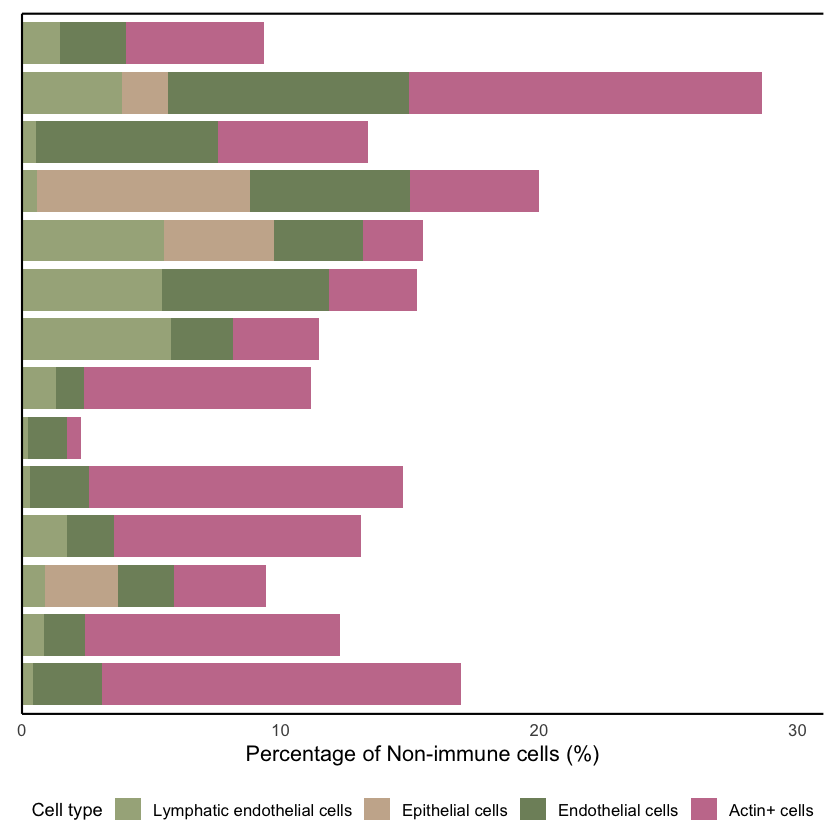

In [712]:
shared_margin <- margin(t = 5, r = 10, b = 5, l = 10)
p_nonimmune = ggplot(
  nonimmune_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = non_immune_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of Non-immune cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )
p_nonimmune

In [713]:
library(patchwork)

combined <- p_main + p_myeloid + p_lymphoid + p_nonimmune +
  plot_layout(ncol = 4, guides = "collect") &   # shared legend (optional)
  theme(legend.position = "bottom")


In [714]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/celltype_composition_combined.svg",
  plot = combined,
  device = "svg",
  width = 25,
  height = 7,
  dpi = 300,
)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


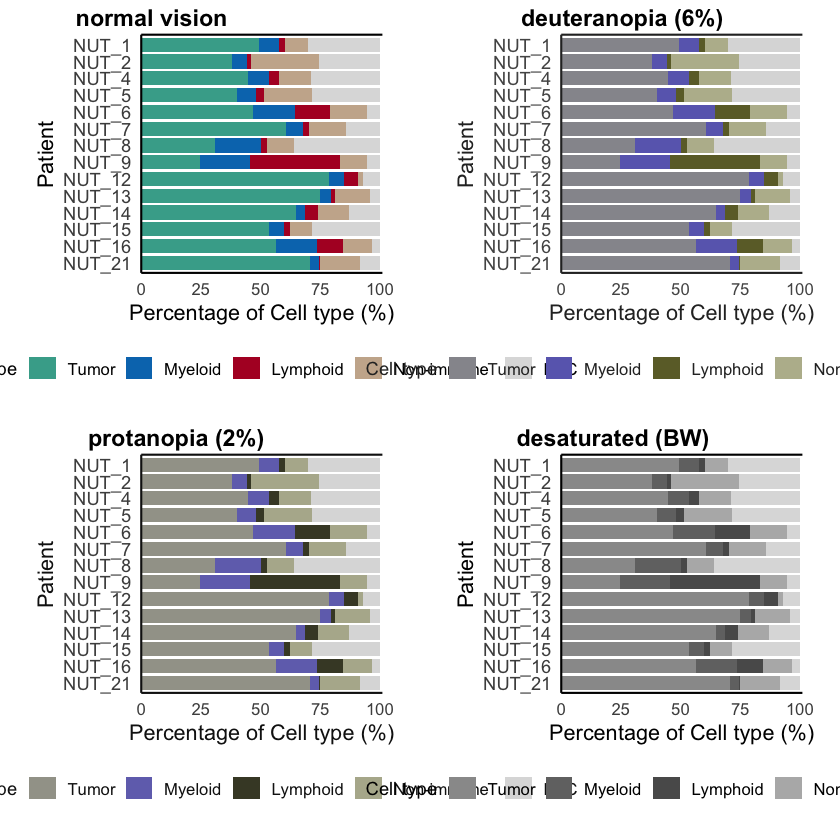

In [624]:
colorBlindness::cvdPlot(p_main)

In [355]:
#calculating myeloid to lymphoid ratios...
ratios_df <- celltype_metadata %>%
  group_by(patient_ID, cell_category_simplified) %>%
  summarise(n = n(), .groups = "drop") %>%
  pivot_wider(names_from = cell_category_simplified, values_from = n, values_fill = 0) %>%
  mutate(
    myeloid_to_lymphoid_ratio = log2(Myeloid / Lymphoid),
    patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
  ) %>%
  arrange(desc(patient_num)) %>%
  mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_"))
  #let's add a column of granulocyte to lymphoid ratio


granulocytes_to_lymphoid_ratio <- celltype_metadata %>%
group_by(patient_ID, cell_category) %>%
summarise(n = n(), .groups = "drop") %>%
pivot_wider(names_from = cell_category, values_from = n, values_fill = 0) %>%
mutate(
    patient_num = as.numeric(str_extract(patient_ID, "\\d+"))
  ) %>%
arrange(desc(patient_num)) %>%
mutate(patient_ID = str_replace(patient_ID, "^NMC_", "NUT_"))  %>%
mutate(Macrophages = `M1 macrophages` + `M2 macrophages` + `M1/M2 macrophages`) %>%
select(patient_ID, Granulocytes, Macrophages)

In [356]:
ratios_df = ratios_df %>%
left_join(granulocytes_to_lymphoid_ratio, by = "patient_ID") %>%
mutate(
  granulocytes_to_lymphoid_ratio = log2(`Granulocytes` / Lymphoid),
  macrophages_to_lymphoid_ratio = log2(Macrophages / Lymphoid)
)

In [365]:
patient_levels <- ratios_df$patient_ID  # keep current order

# Long format + labels
ratios_long2 <- ratios_df %>%
  mutate(patient_ID = factor(patient_ID, levels = patient_levels)) %>%
  pivot_longer(
    cols = c(
      granulocytes_to_lymphoid_ratio,
      macrophages_to_lymphoid_ratio,
      myeloid_to_lymphoid_ratio
    ),
    names_to = "ratio_type",
    values_to = "ratio_value"
  ) %>%
  mutate(
    ratio_type = recode(
      ratio_type,
      granulocytes_to_lymphoid_ratio = "Granulocytes / Lymphoid",
      macrophages_to_lymphoid_ratio  = "Macrophages / Lymphoid",
      myeloid_to_lymphoid_ratio      = "Myeloid / Lymphoid"
    ),
    panel = ifelse(ratio_type == "Myeloid / Lymphoid", "Myeloid (aggregate)", "Subsets")
  )

ratios_plot = ggplot(ratios_long2, aes(x = ratio_value, y = patient_ID, color = ratio_type)) +
  geom_vline(xintercept = 0, linetype = "dotted", color = "grey40") +
  geom_point(size = 3, alpha = 0.9) +
  facet_wrap(~ panel, ncol = 2, scales = "free_x") +
  labs(
    x = "Logged ratio value",
    y = "Patient",
    color = "Ratio",
    title = "Immune composition ratios across patients"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.y = element_line(color = "grey90"),
    strip.text = element_text(face = "bold"),
    plot.title = element_text(face = "bold"),
    legend.position = "right",
    # facet borders (box around each panel)
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6)
  ) +
  scale_x_continuous(
    breaks = breaks_pretty(n = 5),
    expand = expansion(mult = c(0.05, 0.08))
  )

ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/immune_composition_ratios.svg",
  plot = ratios_plot,
  width = 10,
  height = 6,
  dpi = 300
)


In [ ]:
np <- import("numpy")
results_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/"
patient_name <- "NMC_1_ROI1"

# Load meta JSON
meta_path <- file.path(results_dir, paste0(patient_name, "_meta.json"))
meta <- fromJSON(meta_path)

# Load distance matrix (.npy)
D_out_path <- file.path(results_dir, paste0(patient_name, "_dist_out.npy"))
D_out <- np$load(D_out_path)


In [145]:
cell_category_color_lymphoid <- c(
  "CD4+ T cells"  = "#0072B2",  # deep blue
  "CD8+ T cells"  = "#56B4E9",  # sky blue (lighter than CD4)
  "Treg T cells"  = "#CC79A7",  # reddish purple
  "NK cells"      = "#009E73",  # bluish green
  "B cells"       = "#F0E442",  # yellow
  "PCs"           = "#E69F00"   # orange
)
cell_category_color_myeloid <- c(
  "M1 macrophages"     = "#D55E00",  # vermillion
  "M2 macrophages"     = "#E69F00",  # orange
  "M1/M2 macrophages"  = "#8C510A",  # brown

  "DCs"                = "#AA4499",  # purple
  "Granulocytes"       = "#882255",  # wine/magenta
  "MDSCs"              = "#332288",  # indigo
  "Mast cells"         = "#999933"   # olive
)


In [150]:
celltype_metadata <- readr::read_csv(
  paste0(results_dir, "/celltype_metadata_final.csv")
)

celltype_percentage_patient = celltype_metadata %>%
  group_by(patient_ID, cell_category) %>%
  summarise(n = n()) %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100)

lymphoid_levels <- names(cell_category_color_lymphoid)
myeloid_levels  <- names(cell_category_color_myeloid)

df_lymphoid <- celltype_percentage_patient %>%
  filter(cell_category %in% lymphoid_levels) %>%
  mutate(cell_category = factor(cell_category, levels = lymphoid_levels))

df_myeloid <- celltype_percentage_patient %>%
  filter(cell_category %in% myeloid_levels) %>%
  mutate(cell_category = factor(cell_category, levels = myeloid_levels))


Rows: 578608 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): cell_type, cell_category, patient_ID, exp_name, patient_exp, sample...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months
lgl (1): is_sample_primary

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'patient_ID'. You can override using the
`.groups` argument.


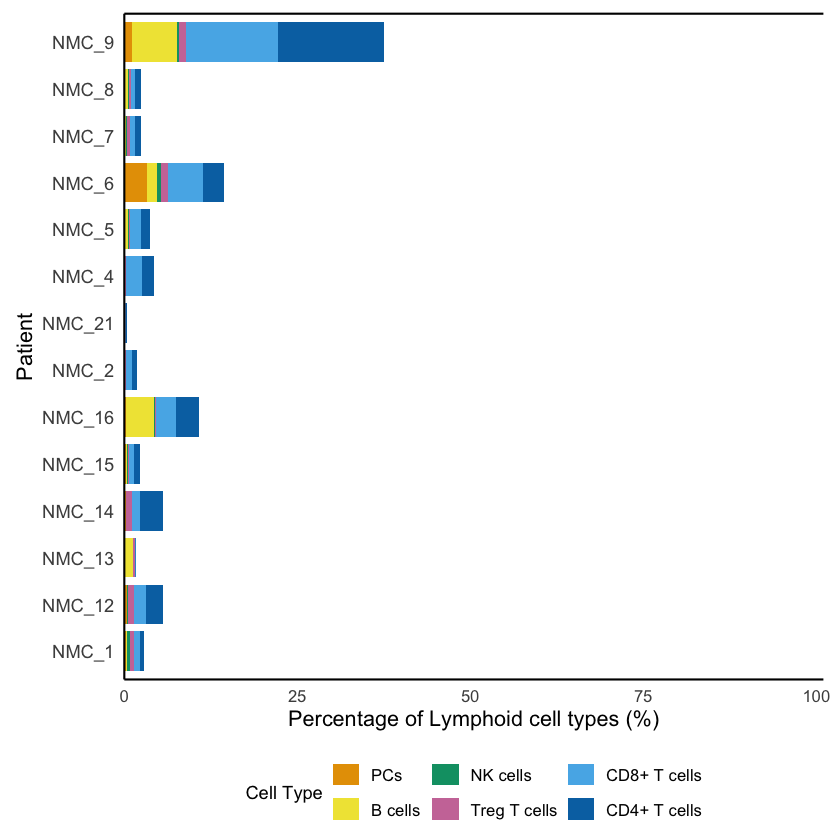

In [153]:
plot_lymphoid <- ggplot(
  df_lymphoid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = cell_category_color_lymphoid) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of Lymphoid cell types (%)",
    y = "Patient",
    fill = "Cell Type"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    plot.margin = shared_margin
  )
plot_lymphoid

In [ ]:
#barplot of total number of cells
anno_right <- ggplot(patient_cell_counts, aes(x = patient_ID, y = total_cells)) +
  geom_bar(stat = "identity", fill = "darkgrey") +
  theme_minimal() +
  theme(
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
  ) +
  ylab("Total cells") +
  scale_y_continuous(expand = c(0, 0), breaks = c(0,45000, 90000), sec.axis = dup_axis()) +
  coord_flip() +
  theme(
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
  panel.border = element_blank(),  # remove full box

  # X axis lines
  axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
  axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),

  # Y axis lines
  axis.line.y.left   = element_line(colour = "black", linewidth = 0.6),
  axis.line.y.right  = element_blank(),  # remove right side

  panel.grid = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  plot.margin = shared_margin)
anno_right 

In [ ]:
anno_top <- ggplot(
  patient_tissue,
  aes(
    x    = 1,        # 🔑 dummy DISCRETE axis
    y    = patient_ID,
    fill = sample_tissue,
  )
) +
  geom_tile(height = 0.95) +   # controls block thickness ONLY
  scale_y_discrete(expand = c(0, 0)) +   # 🔑 remove spacing
  labs(fill = "Sample Tissue") +
  theme_void(base_size = 13) +
  theme(
    plot.margin     = margin(0, 0, 0, 0),
    legend.position = "right"
  )
anno_top

In [53]:
colorspace::simulate_cvd()

ERROR: Error in simulate_cvd(main_plot, type = "deutan"): unused argument (type = "deutan")


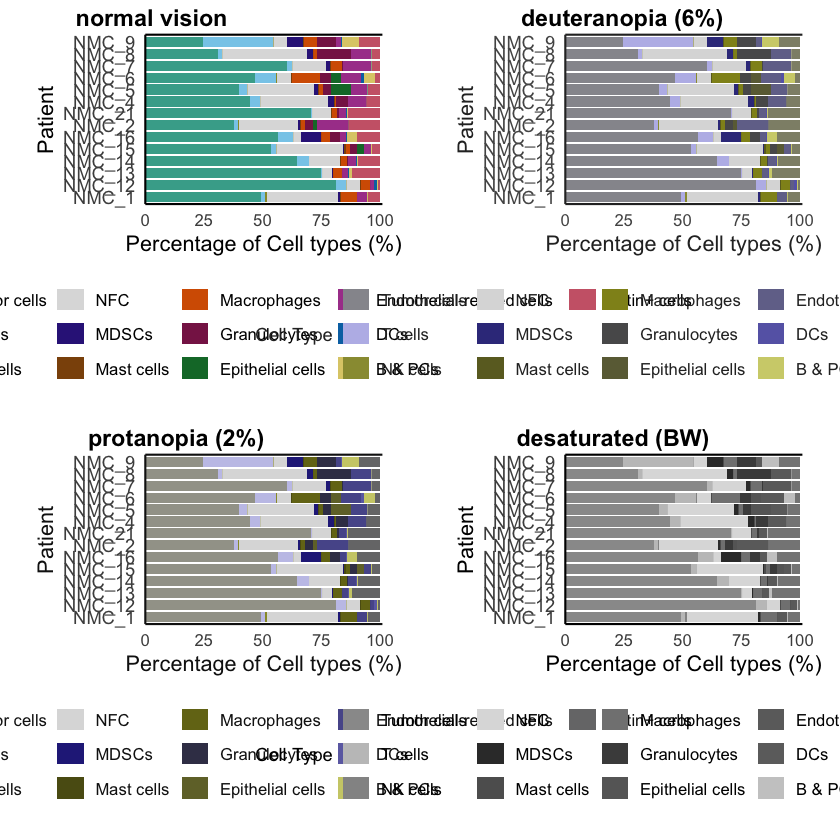

In [59]:
colorBlindness::cvdPlot(main_plot)

In [715]:
full_palette <- c(
  # Myeloid
  "MDSCs"             = "#332288",
  "M2 macrophages"    = "#66A61E",
  "M1 macrophages"    = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs"               = "#E69F00",
  "Granulocytes"      = "#B85AA6",
  "Mast cells"        = "#8E006A",

  # Lymphoid
  "CD8+ T cells"      = "#B2182B",
  "CD4+ T cells"      = "#EF8A62",
  "Treg T cells"      = "#FFCCCC",
  "NK cells"          = "#0096FF",
  "B cells"           = "#E6C84F",
  "PCs"               = "#F4E58A",

  # Non-immune
  "Actin+ cells"                  = "#C77C9B",
  "Endothelial cells"             = "#7F8F6A",
  "Lymphatic endothelial cells"   = "#A6B08A",
  "Epithelial cells"              = "#C9B29B",

  # Other
  "Tumor cells"       = "#44AA99",
  "NFC"               = "#DDDDDD"
)



In [399]:

out_dir <- "/Users/jawadalaaedeen/Desktop/paper_figs"

patients <- unique(celltype_metadata$patient_exp)

for (p in patients) {

  df_sub <- subset(celltype_metadata, patient_exp == p)

  p_plot <- ggplot(
    df_sub,
    aes(
      x = `Cell Center X`,
      y = `Cell Center Y`,
      color = cell_category
    )
  ) +
    geom_point(size = 0.5, alpha = 0.9) +
    scale_color_manual(values = full_palette) +
    coord_equal() +
    theme_void() +
    theme(
      legend.position = "none"
    )

  ggsave(
    filename = file.path(out_dir, paste0("spatial_", p, ".png")),
    plot = p_plot,
    width = 5,
    height = 5,
    dpi = 600,
    bg = "white"
  )
}


In [716]:
patient_id <- "NMC_9_ROI4"
out_dir <- "/Users/jawadalaaedeen/Desktop/paper_figs"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# Define crop window (same as python)
x_start <- 2192  # <-- set this
y_start <- 5334  # <-- set this
win <- 2000

df <- celltype_metadata %>%
  filter(patient_exp == patient_id) %>%
  mutate(cell_category = factor(cell_category, levels = names(full_palette))) %>%
  filter(
    `Cell Center X` >= x_start, `Cell Center X` <= x_start + win,
    `Cell Center Y` >= y_start, `Cell Center Y` <= y_start + win
  )


In [721]:
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1,
                           pt_size_bg = 1.5, pt_size_fg = 1.5) {

  df_bg <- df %>% dplyr::filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% dplyr::filter(cell_category %in% highlight_levels)

  # palette restricted to highlighted cells (keeps your exact colors)
  pal_hl <- full_palette[highlight_levels]
  pal_hl <- pal_hl[!is.na(pal_hl)]  # safety if some names not present

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = pal_hl,
      breaks = highlight_levels,   # <- legend entries limited to highlighted
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "right"
    ) +
    ggtitle(title) +
    scale_y_reverse()
} 


In [722]:
p <- plot_highlight(
  df,
  highlight_levels = c("CD8+ T cells", "CD4+ T cells", "Treg T cells"))

ggsave(filename = file.path("/Users/jawadalaaedeen/Desktop/spatial_highlight_lymphoid.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")


In [425]:
# Define crop window (same as python)
x_start <- 12192  # <-- set this
y_start <- 5363  # <-- set this
win <- 2000

df <- celltype_metadata %>%
  filter(patient_exp == patient_id) %>%
  mutate(cell_category = factor(cell_category, levels = names(full_palette))) %>%
  filter(
    `Cell Center X` >= x_start, `Cell Center X` <= x_start + win,
    `Cell Center Y` >= y_start, `Cell Center Y` <= y_start + win
  )


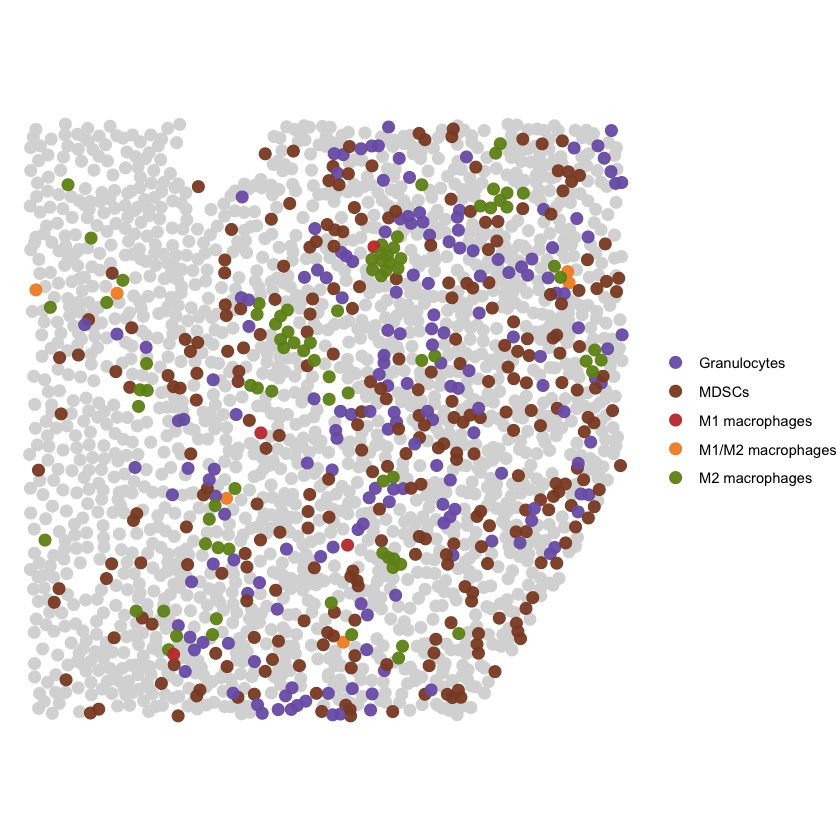

In [426]:
p <- plot_highlight(
  df,
  highlight_levels = c("Granulocytes", "MDSCs", "M1 macrophages", "M1/M2 macrophages", "M2 macrophages"))

p

In [723]:
# Define crop window (same as python)
x_start <- 7580  # <-- set this
y_start <- 5200  # <-- set this
win <- 2000

df <- celltype_metadata %>%
  filter(patient_exp == patient_id) %>%
  mutate(cell_category = factor(cell_category, levels = names(full_palette))) %>%
  filter(
    `Cell Center X` >= x_start, `Cell Center X` <= x_start + win,
    `Cell Center Y` >= y_start, `Cell Center Y` <= y_start + win
  )


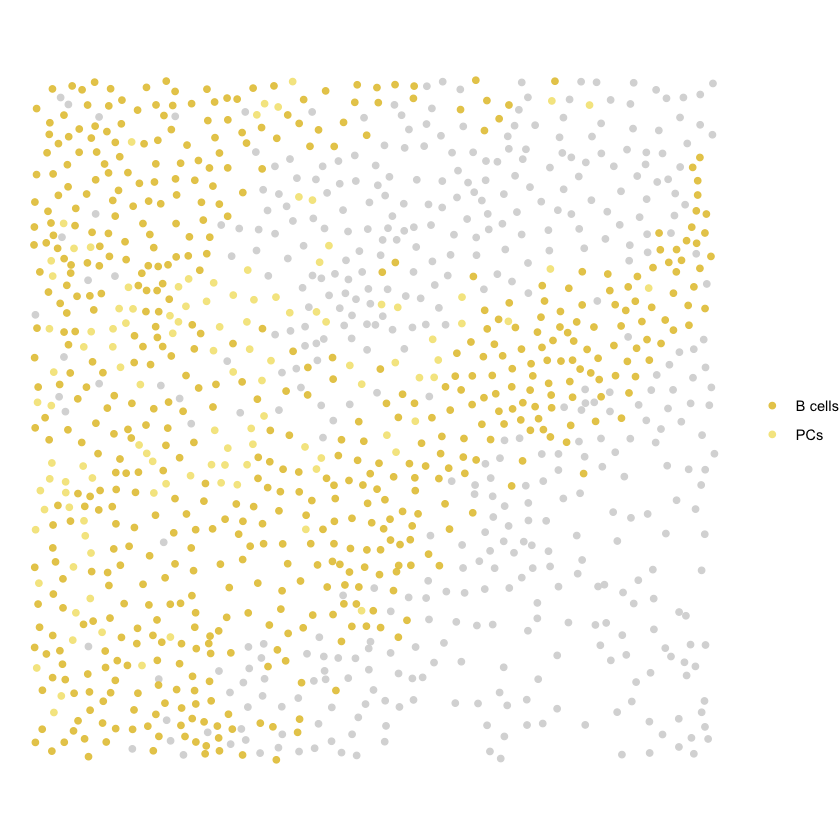

In [724]:
p <- plot_highlight(
  df,
  highlight_levels = c("B cells", "PCs"))
p

ggsave(filename = file.path("/Users/jawadalaaedeen/Desktop/spatial_highlight_lymphoid_B.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")


In [430]:
df <- celltype_metadata %>%
  filter(patient_exp == patient_id) %>%
  mutate(cell_category = factor(cell_category, levels = names(full_palette)))


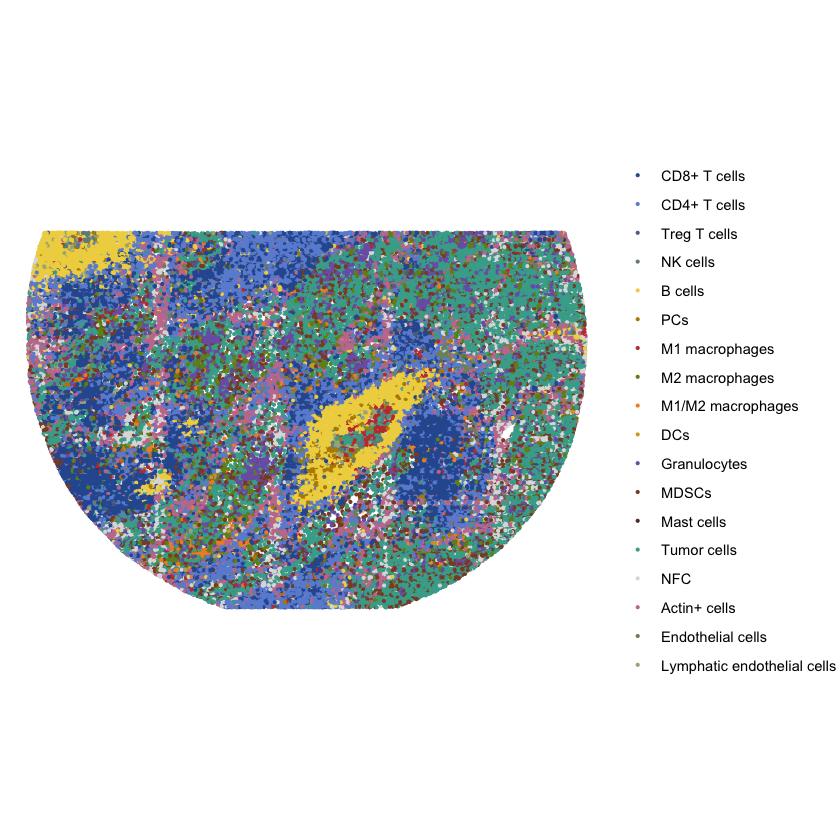

In [434]:
ggplot() +
    geom_point(
      data = df,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 1,
      size = 0.50
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "right"
    ) +
    scale_color_manual(
      values = full_palette
    ) +
    scale_y_reverse() 

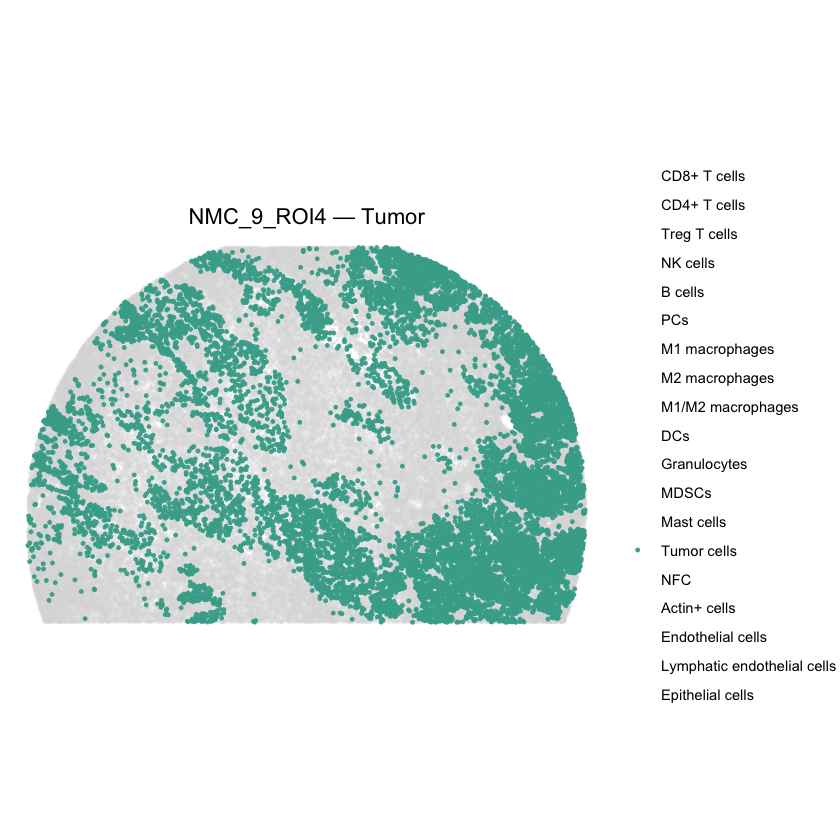

In [400]:
patient_id <- "NMC_9_ROI4"
out_dir <- "/Users/jawadalaaedeen/Desktop/paper_figs"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

df <- celltype_metadata %>%
  filter(patient_exp == patient_id) %>%
  mutate(cell_category = factor(cell_category, levels = names(full_palette)))

# Helper: grey background + colored highlight
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 0.35,
                           pt_size_bg = 0.45, pt_size_fg = 0.7) {

  df_bg <- df %>% filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% filter(cell_category %in% highlight_levels)

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(values = full_palette, drop = FALSE) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "right"
    ) +
    ggtitle(title)
}



# Make + save
plots <- list()

for (nm in names(highlight_sets)) {
  hl <- highlight_sets[[nm]]

  p <- plot_highlight(
    df,
    highlight_levels = hl,
    title = paste(patient_id, "—", nm)
  )

  plots[[nm]] <- p

  ggsave(
    filename = file.path(out_dir, paste0(patient_id, "_", nm, ".png")),
    plot = p,
    width = 5.5,
    height = 5.5,
    dpi = 600,
    bg = "white"
  )
}

# Show one of them in the RStudio viewer if you want:
plots[["Tumor"]]


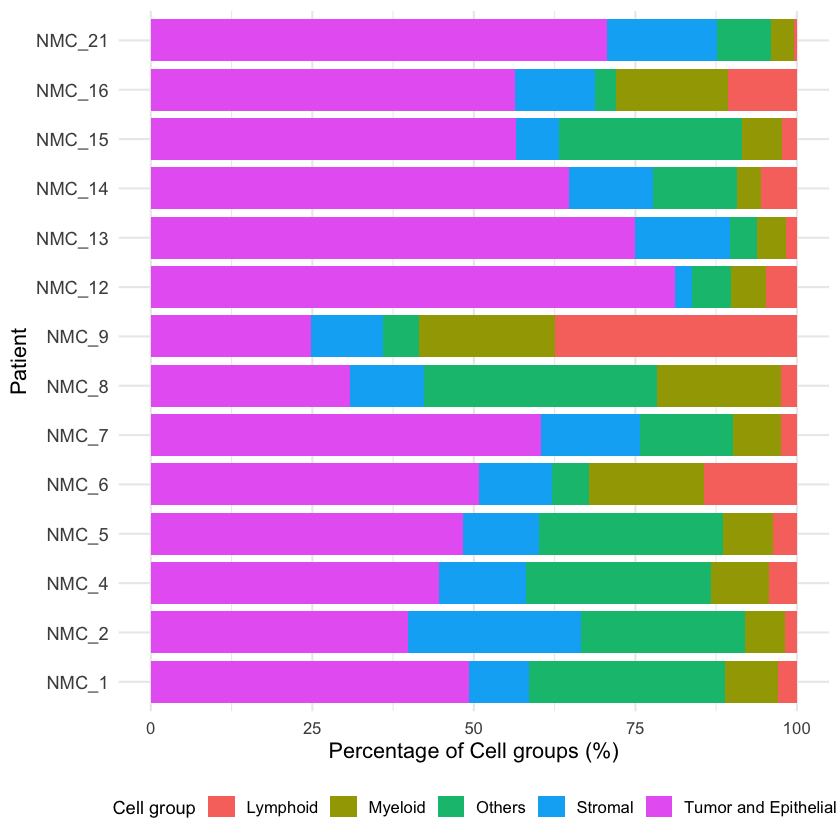

In [147]:
ggplot(
  celltype_percentage_patient_group,
  aes(x = patient_ID, y = percentage, fill = cell_group),
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  labs(
    x = "Patient",
    y = "Percentage of Cell groups (%)",
    fill = "Cell group"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom"

  )

In [148]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/cellgroup_percentage_patient_legend.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)


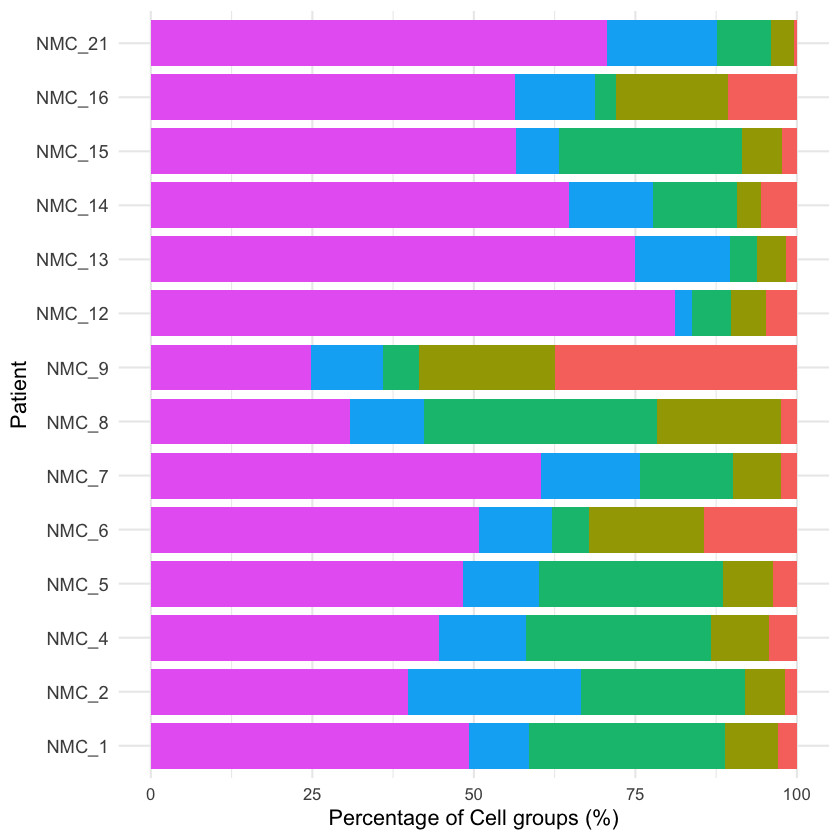

In [149]:
ggplot(
  celltype_percentage_patient_group,
  aes(x = patient_ID, y = percentage, fill = cell_group),
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  labs(
    x = "Patient",
    y = "Percentage of Cell groups (%)",
    fill = "Cell group"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none"

  )

In [150]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/cellgroup_percentage_patient_nolegend.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)


In [163]:
#next up would be to compare the cell types across the sample tissue
#get percentages of cell types per patient
celltype_percentage_tissue = celltype_metadata %>%
  group_by(sample_tissue, cell_category) %>%
  summarise(n = n()) %>%
  group_by(sample_tissue) %>%
  mutate(percentage = n / sum(n) * 100) %>%
  arrange(sample_tissue)

`summarise()` has grouped output by 'sample_tissue'. You can override using the
`.groups` argument.


In [167]:
#Distances plot 
distances <- read_csv("/Users/jawadalaaedeen/Desktop/NMC_distance_to_tumor_cells_per_patient.csv", show_col_types = FALSE)

In [168]:
#filter distances for non immune cells
distances <- distances %>%
  filter(!cell_category %in% c("NFC", "Tumor cells", "Epithelial cells", "Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells"))
#scale distances per patient_exp between 0 and 1
distances <- distances %>%
  group_by(patient_exp) %>%
  mutate(z_robust = (`Tumor cells` - median(`Tumor cells`, na.rm=TRUE)) /
                     mad(`Tumor cells`, na.rm=TRUE))

In [169]:
distances <- distances %>%
  group_by(patient_exp) %>%
  mutate(dist_rank = rank(`Tumor cells`, ties.method = "average")) %>%
  mutate(dist_rank_scaled = dist_rank / max(dist_rank))

In [171]:
myeloid <- c("MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
             "Granulocytes", "Mast cells", "DCs")
lymphoid <- c("B cells", "PCs", "NK cells", "CD4+ T cells", "CD8+ T cells", "Treg T cells")

distances <- distances %>%
  mutate(
    compartment = case_when(
      cell_category %in% myeloid  ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid")
  ) %>%
  mutate(
    cell_category = factor(cell_category, levels = c(myeloid, lymphoid)),
    compartment   = factor(compartment, levels = c("Myeloid", "Lymphoid"))
  )

In [127]:
library(circlize)
library(ComplexHeatmap)

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))


Loading required package: grid

ComplexHeatmap version 2.23.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps in

In [146]:
# ----------------------------------------------------
# 3) Build the matrix (rows=cell types, cols=samples)
#    Use zscore (or switch to `Tumor cells` if desired)
# ----------------------------------------------------
mat <- distances %>%
  select(patient_exp, cell_category, zscore) %>%
  pivot_wider(names_from = patient_exp, values_from = zscore) %>%
  arrange(cell_category)

mat_rownames <- mat$cell_category
mat <- as.matrix(mat[, -1, drop = FALSE])
rownames(mat) <- mat_rownames

# -----------------------------
# 5) Color scheme (purple->white)
# -----------------------------
col_fun <- circlize::colorRamp2(
  c(-1, 0, 1),
  c("#6A00A8","#FFFFFF", "#D9A6E5")
)

# Row split vector in the same order as the matrix rows
row_split_vec <- ifelse(rownames(mat) %in% myeloid, "Lymphoid", "Myeloid")

# -----------------------------
# 6) Draw heatmap
# -----------------------------
svglite::svglite(filename = "~/Desktop/heatmap_output_distance.svg", width = 12, height = 8)


ht <- ComplexHeatmap::Heatmap(
  mat,
  name = "Scaled distance",
  col = col_fun,
  na_col = "grey85",
  column_title = "Average Euclidean distance to Tumor cells by sample",
  row_title = NULL,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 45,
  row_split = row_split_vec,      # Myeloid vs Lymphoid split
  row_gap = unit(2, "mm"),         # visual separator between splits
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  heatmap_legend_param = list(
    title = "Scaled distance",
    at = c(-1, 0, 1)
  ),
 row_names_side = "left",
 column_names_gp = gpar(fontsize = 8),
 row_names_gp = gpar(fontsize = 8),
 column_title_gp = gpar(fontsize = 11, fontface = "bold"),
 row_title_gp = gpar(fontsize = 11, fontface = "bold")
)

draw(ht)

dev.off()


pdf 
  2

In [177]:
# ----------------------------------------------------
# 3) Build the matrix (rows=cell types, cols=samples)
#    Use zscore (or switch to `Tumor cells` if desired)
# ----------------------------------------------------
mat <- distances %>%
  select(patient_exp, cell_category, zscore) %>%
  pivot_wider(names_from = patient_exp, values_from = zscore) %>%
  arrange(cell_category)

mat_rownames <- mat$cell_category
mat <- as.matrix(mat[, -1, drop = FALSE])
rownames(mat) <- mat_rownames

# -----------------------------
# 5) Color scheme (purple->white)
# -----------------------------
col_fun <- circlize::colorRamp2(
  c(-1, 0, 1),
  c("#6A00A8","#FFFFFF", "#D9A6E5")
)

# Row split vector in the same order as the matrix rows
row_split_vec <- ifelse(rownames(mat) %in% myeloid, "Lymphoid", "Myeloid")

# -----------------------------
# 6) Draw heatmap
# -----------------------------
svglite::svglite(filename = "~/Desktop/heatmap_output_distance.svg", width = 12, height = 8)


ht <- ComplexHeatmap::Heatmap(
  mat,
  name = "Scaled distance",
  col = col_fun,
  na_col = "grey85",
  column_title = "Average Euclidean distance to Tumor cells by sample",
  row_title = NULL,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 45,
  row_split = row_split_vec,      # Myeloid vs Lymphoid split
  row_gap = unit(2, "mm"),         # visual separator between splits
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  heatmap_legend_param = list(
    title = "Scaled distance",
    at = c(-1, 0, 1)
  ),
 row_names_side = "left",
 column_names_gp = gpar(fontsize = 8),
 row_names_gp = gpar(fontsize = 8),
 column_title_gp = gpar(fontsize = 11, fontface = "bold"),
 row_title_gp = gpar(fontsize = 11, fontface = "bold")
)

draw(ht)

dev.off()


pdf 
  2

In [ ]:
#Extract the patient numbers between the two underscores from infiltration_me_mat$patient_ID

infiltration_me <- infiltration_me %>%
  mutate(patient_nb = str_extract(patient_exp, "(?<=_)[^_]+(?=_)")) %>%
  #make column numeric
  mutate(patient_nb = as.numeric(patient_nb))

infiltration_me_mat <- infiltration_me %>%
  select(!c(total_cells, infiltration, X)) %>%
  arrange(patient_nb, factor(cell_type, levels = median_infiltration_me$cell_type)) %>%
  select(!patient_nb) %>%
  pivot_wider(names_from = "patient_exp", values_from = "percentage") %>%
  column_to_rownames(var = "cell_type") %>%
  as.matrix()

#give me the order of columns here
column_order <- colnames(infiltration_me_mat)



main_col_fun = colorRamp2(
  c(0.25, 0.5, 1), 
  c("#0055FF", "#f7f7f7", "#FF0000FF")
)


row_ha = rowAnnotation(
  "median_infiltration" = median_infiltration_me$median_infiltration,
  annotation_name_gp = gpar(fontsize = 8),
  annotation_name_rot = 45,
  show_annotation_name = FALSE
)

#Let's save the heatmap as svg



ht = Heatmap(infiltration_me_mat,
        name = "Infiltration",
        col = main_col_fun,
        column_names_rot = 45,
        right_annotation = row_ha,
        row_split = cells_split,
        border = TRUE,
        heatmap_legend_param = list(title = "Infiltration"),
        cluster_rows  = FALSE,
        cluster_columns = FALSE,
        column_title = "Samples",
        row_title = "Cell Types",
        row_names_side = "left",
        column_names_gp = gpar(fontsize = 8),
        row_names_gp = gpar(fontsize = 8),
        column_title_gp = gpar(fontsize = 11, fontface = "bold"),
        row_title_gp = gpar(fontsize = 11, fontface = "bold"),
)

draw(ht)

dev.off()

In [21]:
# What an insane shit we are doing
ppm_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/ppm_export"  # folder with *_dist_out.npy etc.
cells_csv <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/cells_with_signed_dist.csv"
out_csv <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/ppm_beta1_results.csv"

In [2]:
library(spatstat.geom)
library(spatstat.model)
library(RcppCNPy)
library(jsonlite)
library(data.table)


Warning message:
“package ‘spatstat.geom’ was built under R version 4.4.3”
Loading required package: spatstat.data

Loading required package: spatstat.univar

Warning message:
“package ‘spatstat.univar’ was built under R version 4.4.3”
spatstat.univar 3.1-6

spatstat.geom 3.7-0

Warning message:
“package ‘spatstat.model’ was built under R version 4.4.3”
Loading required package: spatstat.random

Warning message:
“package ‘spatstat.random’ was built under R version 4.4.3”
spatstat.random 3.4-4

Loading required package: spatstat.explore

Warning message:
“package ‘spatstat.explore’ was built under R version 4.4.3”
Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


spatstat.explore 3.7-0

Loading required package: rpart

spatstat.model 3.6-1


Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten


Warning message:
“package ‘data.table’ was built under R version 4.4.

In [17]:
load_roi_covariates <- function(roi_tag, ppm_dir) {
  dist_path <- file.path(ppm_dir, paste0(roi_tag, "_dist_out.npy"))
  win_path  <- file.path(ppm_dir, paste0(roi_tag, "_W_outside.npy"))
  meta_path <- file.path(ppm_dir, paste0(roi_tag, "_meta.json"))

  meta <- jsonlite::fromJSON(meta_path)

  dist_raw <- RcppCNPy::npyLoad(dist_path)
  mask_raw <- RcppCNPy::npyLoad(win_path)

  dist_mat <- as.matrix(dist_raw)
  storage.mode(dist_mat) <- "double"

  mask_mat <- as.matrix(mask_raw) > 0

  # --- remove NaN/Inf from inside window ---
  bad <- !is.finite(dist_mat)
  if (any(bad & mask_mat)) {
    mask_mat[bad] <- FALSE    # drop those pixels from W
  }
  # fill bad pixels with 0 (outside W anyway)
  dist_mat[bad] <- 0

  ny <- nrow(dist_mat); nx <- ncol(dist_mat)
  x_min <- meta$x_min; y_min <- meta$y_min; gs <- meta$grid_size
  xcol <- x_min + (0:(nx-1)) * gs
  yrow <- y_min + (0:(ny-1)) * gs

  D <- spatstat.geom::im(mat=dist_mat, xcol=xcol, yrow=yrow)
  W <- spatstat.geom::as.owin(spatstat.geom::im(mat=mask_mat, xcol=xcol, yrow=yrow))

  D <- D[W]

  stopifnot(spatstat.geom::is.im(D))
  stopifnot(spatstat.geom::is.owin(W))

  list(D=D, W=W, meta=meta)
}


In [18]:
cells <- fread(cells_csv)

# ---- change these to match YOUR labels ----
immune_labels <- c(
  "CD8+ T cells", "CD4+ T cells", "Treg T cells", "NK cells", "B cells",
  "M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "Granulocytes", "MDSCs", "Mast cells", "DCs", "PCs"
)

In [ ]:
cts <- data.table::fread(file.path(ppm_dir, "NMC_1_ROI1.csv"))

head(cts)

x0,y0,x1,y1
<dbl>,<dbl>,<dbl>,<dbl>
5786.954,220.8669,5771.954,235.8669
5771.954,235.8669,5741.954,235.8669
5741.954,235.8669,5726.954,250.8669
5726.954,250.8669,5711.954,265.8669
5711.954,265.8669,5696.954,280.8669
5696.954,280.8669,5681.954,295.8669


In [25]:
cells <- fread(cells_csv)
cells

patient_exp,Cell Center X,Cell Center Y,cell_category,tumor_signed_dist_to_contour_um
<chr>,<dbl>,<dbl>,<chr>,<dbl>
NMC_1_ROI3,10631.4121,2069.749,M1/M2 macrophages,-27.464341
NMC_1_ROI3,8845.2061,2724.693,NFC,-27.464341
NMC_1_ROI3,7723.4414,2733.565,Tumor cells,-14.424978
NMC_1_ROI3,4202.7114,2745.385,Tumor cells,-57.019733
NMC_1_ROI3,236.6398,2731.067,Tumor cells,-43.274935
NMC_1_ROI3,8747.2461,2733.468,NFC,-21.637468
NMC_1_ROI3,7648.7910,2724.897,Tumor cells,-7.212489
NMC_1_ROI3,6815.2275,2733.575,Tumor cells,-10.200000
NMC_1_ROI3,2355.1128,2734.792,Tumor cells,-5.100000


In [27]:
roi <- "NMC_1_ROI1"
df <- cells[patient_exp == roi]
df

patient_exp,Cell Center X,Cell Center Y,cell_category,tumor_signed_dist_to_contour_um
<chr>,<dbl>,<dbl>,<chr>,<dbl>
NMC_1_ROI1,5951.2944,509.0007,Tumor cells,-21.637468
NMC_1_ROI1,4631.5049,1859.5930,Tumor cells,-47.019677
NMC_1_ROI1,6247.6016,1852.5942,NFC,-7.212489
NMC_1_ROI1,292.1319,1865.8739,NFC,45.900000
NMC_1_ROI1,6053.0752,1863.6669,Tumor cells,5.100000
NMC_1_ROI1,4068.7039,1867.3218,Tumor cells,-25.500000
NMC_1_ROI1,5112.9429,1877.1473,Tumor cells,-28.849957
NMC_1_ROI1,3788.7395,1868.6558,Tumor cells,-25.500000
NMC_1_ROI1,4265.7656,1874.4058,Tumor cells,-18.388312


In [ ]:
re

In [39]:
meta <- fromJSON(paste0("/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/ppm_export/NMC_1_ROI1_meta.json"))
D_out <- np$load("/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/ppm_export/NMC_1_ROI1_dist_out.npy")
W_out <- np$load("/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/ppm_export/NMC_1_ROI1_W_outside.npy")

1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,1


In [44]:
np <- import("numpy")

# --- load your exports for one ROI ---
roi_tag <- "NMC_1_ROI1"

nx <- meta$nx; ny <- meta$ny
x_min <- meta$x_min; y_min <- meta$y_min; grid <- meta$grid_size

# define spatial ranges for pixel image
xrange <- c(x_min, x_min + (nx-1)*grid)
yrange <- c(y_min, y_min + (ny-1)*grid)

# spatstat pixel images: matrix is [row=y, col=x]
D_im <- as.im(as.matrix(D_out), W = owin(xrange=xrange, yrange=yrange))
W_im <- as.im(as.matrix(W_out), W = owin(xrange=xrange, yrange=yrange))

# window = where W_out == 1
Win <- as.owin(W_im > 0.5)

# read cell table for this ROI
cells <- fread("/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/cell_positions_and_distances.csv")
cells <- cells[patient_exp == roi_tag]

# keep only points inside Win (important if any coords fall outside)
inside <- inside.owin(cells$x, cells$y, Win)
cells <- cells[inside, ]


In [67]:


np <- import("numpy")
results_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/"
patient_name <- "NMC_1_ROI1"

In [94]:
np <- import("numpy")
results_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/"
patient_name <- "NMC_1_ROI1"

# Load meta JSON
meta_path <- file.path(results_dir, paste0(patient_name, "_meta.json"))
meta <- fromJSON(meta_path)

# Load distance matrix (.npy)
D_out_path <- file.path(results_dir, paste0(patient_name, "_dist_out.npy"))
D_out <- np$load(D_out_path)


In [95]:

x <- meta$nx; ny <- meta$ny
x_min <- meta$x_min; y_min <- meta$y_min; grid <- meta$grid_size

xrange <- c(x_min, x_min + (nx-1)*grid)
yrange <- c(y_min, y_min + (ny-1)*grid)

Win <- owin(xrange=xrange, yrange=yrange)

D_mat <- as.matrix(D_out)
D_mat <- D_mat / 100
D_im <- as.im(D_mat, W=Win)


cells <- fread("/Users/jawadalaaedeen/Desktop/cells_df.csv")
cells <- cells[patient_exp == patient_name]

# keep inside bbox (just in case)
cells <- cells[inside.owin(`Cell Center X`, `Cell Center Y`, Win) == TRUE]

In [97]:
if ("tumor_territory" %in% names(cells)) {
  cells <- cells[tumor_territory == FALSE]
} else if ("tumor_signed_dist_to_contour" %in% names(cells)) {
  cells <- cells[tumor_signed_dist_to_contour > 0]
} else {
  stop("Need tumor_territory or tumor_signed_dist_to_contour in cells table to filter outside tumor.")
}

In [104]:
min_cells <- 10

# assume you already have:
# Win, D_im, and filtered `cells` for this ROI:
# - correct ROI subset
# - inside.owin TRUE
# - outside-only (signed_dist > 0 or tumor_territory == FALSE)
# - tumor cells removed

cell_col <- "cell_category"  # CHANGE if your column is named differently

cts <- unique(cells[[cell_col]])
out <- list()

for (ct in cts) {
  pts <- cells[get(cell_col) == ct]
  if (nrow(pts) < min_cells) next

  X <- ppp(
    x = pts$`Cell Center X`,
    y = pts$`Cell Center Y`,
    window = Win
  )

  fit <- ppm(X ~ D_im)

  beta0 <- unname(coef(fit)[1])
  beta1 <- unname(coef(fit)[2])   # coefficient for distance covariate

  out[[ct]] <- data.table(
    roi = patient_name,
    cell_type = ct,
    n = nrow(pts),
    beta0 = beta0,
    beta1 = beta1,
    proximity = -beta1
  )
}

res <- rbindlist(out, fill=TRUE)

# within-ROI normalized rank 0..1 (paper-style)
if (nrow(res) > 0) {
  res[, rank := frank(proximity, ties.method="average")]
  res[, rank01 := if (max(rank) > 1) (rank - 1) / (max(rank) - 1) else 0.5]
}

res[order(-proximity)]

roi,cell_type,n,beta0,beta1,proximity,rank,rank01
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NMC_1_ROI1,M1/M2 macrophages,148,-12.05880,-0.3376544,0.3376544,10,1.0000000
NMC_1_ROI1,CD8+ T cells,94,-12.53439,-0.3218426,0.3218426,9,0.8888889
NMC_1_ROI1,NK cells,32,-13.62470,-0.3147584,0.3147584,8,0.7777778
NMC_1_ROI1,Treg T cells,24,-13.92175,-0.3075854,0.3075854,7,0.6666667
NMC_1_ROI1,M1 macrophages,59,-13.03744,-0.2970882,0.2970882,6,0.5555556
NMC_1_ROI1,CD4+ T cells,31,-13.68433,-0.2950777,0.2950777,5,0.4444444
NMC_1_ROI1,PCs,21,-14.07713,-0.2928511,0.2928511,4,0.3333333
NMC_1_ROI1,MDSCs,32,-13.70898,-0.2618272,0.2618272,3,0.2222222
NMC_1_ROI1,B cells,28,-13.86298,-0.2501580,0.2501580,2,0.1111111


In [105]:
make_win_and_covariate <- function(results_dir, roi_tag, scale_dist=100) {
  meta <- fromJSON(file.path(results_dir, paste0(roi_tag, "_meta.json")))
  D_out <- np$load(file.path(results_dir, paste0(roi_tag, "_dist_out.npy")))

  nx <- meta$nx
  ny <- meta$ny
  x_min <- meta$x_min
  y_min <- meta$y_min
  grid <- meta$grid_size

  xrange <- c(x_min, x_min + (nx - 1) * grid)
  yrange <- c(y_min, y_min + (ny - 1) * grid)

  Win <- owin(xrange=xrange, yrange=yrange)

  D_mat <- as.matrix(D_out)
  if (!is.null(scale_dist) && scale_dist > 0) D_mat <- D_mat / scale_dist
  D_im <- as.im(D_mat, W=Win)

  list(Win=Win, D_im=D_im)
}


In [106]:
filter_cells_outside_immune <- function(cells, roi_tag, Win,
                                       roi_col="patient_exp",
                                       x_col="Cell Center X",
                                       y_col="Cell Center Y",
                                       cell_col="cell_category",
                                       tumor_label="Tumor cells") {

  cells <- cells[get(roi_col) == roi_tag]

  # keep inside bbox
  inside <- inside.owin(cells[[x_col]], cells[[y_col]], Win)
  cells <- cells[inside == TRUE]

  # outside tumor only
  if ("tumor_territory" %in% names(cells)) {
    cells <- cells[tumor_territory == FALSE]
  } else if ("tumor_signed_dist_to_contour" %in% names(cells)) {
    cells <- cells[tumor_signed_dist_to_contour > 0]
  } else {
    stop("Need tumor_territory or tumor_signed_dist_to_contour in cells table.")
  }

  # immune only
  cells <- cells[get(cell_col) != tumor_label]

  cells[]
}

In [107]:
perm_test_beta1 <- function(pts_x, pts_y, Win, D_im,
                            pool_x, pool_y,
                            n_perm=100) {

  # observed
  X_obs <- ppp(pts_x, pts_y, window=Win)
  fit_obs <- ppm(X_obs ~ D_im)
  beta1_obs <- unname(coef(fit_obs)[2])
  prox_obs <- -beta1_obs

  n <- length(pts_x)
  Npool <- length(pool_x)
  if (Npool < n) stop("Pool smaller than cell type population; cannot sample without replacement.")

  prox_perm <- numeric(n_perm)

  for (k in seq_len(n_perm)) {
    idx <- sample.int(Npool, size=n, replace=FALSE)
    Xp <- ppp(pool_x[idx], pool_y[idx], window=Win)
    fit_p <- ppm(Xp ~ D_im)
    beta1_p <- unname(coef(fit_p)[2])
    prox_perm[k] <- -beta1_p
  }

  # one-sided p-value: how often permuted is >= observed (at least as close)
  pval <- (sum(prox_perm >= prox_obs) + 1) / (n_perm + 1)  # +1 smoothing

  list(beta1_obs=beta1_obs, prox_obs=prox_obs, pval=pval)
}


In [108]:
run_one_roi <- function(results_dir, roi_tag, cells,
                        min_cells=10, n_perm=100, scale_dist=100,
                        roi_col="patient_exp",
                        x_col="Cell Center X",
                        y_col="Cell Center Y",
                        cell_col="cell_category",
                        tumor_label="Tumor cells") {

  # build window + covariate
  wd <- make_win_and_covariate(results_dir, roi_tag, scale_dist=scale_dist)
  Win <- wd$Win; D_im <- wd$D_im

  # filter cells
  cf <- filter_cells_outside_immune(cells, roi_tag, Win,
                                   roi_col=roi_col, x_col=x_col, y_col=y_col,
                                   cell_col=cell_col, tumor_label=tumor_label)

  if (nrow(cf) == 0) return(data.table())

  # pool = all immune outside-tumor coords in this ROI
  pool_x <- cf[[x_col]]
  pool_y <- cf[[y_col]]

  out <- list()

  for (ct in unique(cf[[cell_col]])) {
    pts <- cf[get(cell_col) == ct]
    if (nrow(pts) < min_cells) next

    perm <- perm_test_beta1(
      pts_x = pts[[x_col]],
      pts_y = pts[[y_col]],
      Win = Win,
      D_im = D_im,
      pool_x = pool_x,
      pool_y = pool_y,
      n_perm = n_perm
    )

    out[[ct]] <- data.table(
      roi = roi_tag,
      cell_type = ct,
      n = nrow(pts),
      beta1 = perm$beta1_obs,
      proximity = perm$prox_obs,
      pval = perm$pval
    )
  }

  res <- rbindlist(out, fill=TRUE)
  if (nrow(res) == 0) return(res)

  # within-ROI rank01 based on proximity
  res[, rank := frank(proximity, ties.method="average")]
  res[, rank01 := if (max(rank) > 1) (rank - 1)/(max(rank)-1) else 0.5]
  res[]
}


In [109]:
stouffer <- function(pvals) {
  pvals <- pvals[is.finite(pvals) & !is.na(pvals)]
  if (length(pvals) == 0) return(NA_real_)
  z <- qnorm(1 - pvals)
  Z <- sum(z) / sqrt(length(z))
  1 - pnorm(Z)
}

# ---- RUN ALL ----
results_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/"
cells_all <- fread("/Users/jawadalaaedeen/Desktop/cells_df.csv")

roi_tags <- unique(cells_all$patient_exp)

all_res <- rbindlist(lapply(roi_tags, function(roi_tag) {
  cat("ROI:", roi_tag, "\n")
  run_one_roi(
    results_dir = results_dir,
    roi_tag = roi_tag,
    cells = cells_all,
    min_cells = 10,
    n_perm = 100,
    scale_dist = 100
  )
}), fill=TRUE)

fwrite(all_res, file.path(results_dir, "ALL_ppm_beta1perm_roi_level.csv"))

# aggregate across ROIs
agg <- all_res[, .(
  n_rois = uniqueN(roi),
  n_cells_total = sum(n),
  median_rank01 = median(rank01, na.rm=TRUE),
  median_proximity = median(proximity, na.rm=TRUE),
  stouffer_p = stouffer(pval)
), by=cell_type][order(-median_rank01)]

# paper-like filter: keep cell types with at least 6 ROIs surviving min_cells
agg <- agg[n_rois >= 6]

fwrite(agg, file.path(results_dir, "ALL_ppm_beta1perm_aggregate.csv"))


In [110]:
run_one_roi_noperm <- function(results_dir, roi_tag, cells,
                               min_cells=10, scale_dist=100,
                               roi_col="patient_exp",
                               x_col="Cell Center X",
                               y_col="Cell Center Y",
                               cell_col="cell_category",
                               tumor_label="Tumor cells") {

  # build window + covariate
  wd <- make_win_and_covariate(results_dir, roi_tag, scale_dist=scale_dist)
  Win <- wd$Win; D_im <- wd$D_im

  # filter cells
  cf <- filter_cells_outside_immune(cells, roi_tag, Win,
                                   roi_col=roi_col, x_col=x_col, y_col=y_col,
                                   cell_col=cell_col, tumor_label=tumor_label)

  if (nrow(cf) == 0) return(data.table())

  out <- list()

  for (ct in unique(cf[[cell_col]])) {
    pts <- cf[get(cell_col) == ct]
    if (nrow(pts) < min_cells) next

    X <- ppp(pts[[x_col]], pts[[y_col]], window=Win)
    fit <- ppm(X ~ D_im)

    beta1 <- unname(coef(fit)[2])
    out[[ct]] <- data.table(
      roi = roi_tag,
      cell_type = ct,
      n = nrow(pts),
      beta1 = beta1,
      proximity = -beta1
    )
  }

  res <- rbindlist(out, fill=TRUE)
  if (nrow(res) == 0) return(res)

  # normalized rank per ROI
  res[, rank := frank(proximity, ties.method="average")]
  res[, rank01 := if (max(rank) > 1) (rank - 1)/(max(rank)-1) else 0.5]

  res[]
}


In [111]:
cells_all <- fread("/Users/jawadalaaedeen/Desktop/cells_df.csv")
roi_tags <- unique(cells_all$patient_exp)

all_res <- rbindlist(lapply(roi_tags, function(roi_tag) {
  cat("ROI:", roi_tag, "\n")
  run_one_roi_noperm(results_dir, roi_tag, cells_all)
}), fill=TRUE)



ROI: NMC_1_ROI3 
ROI: NMC_1_ROI1 
ROI: NMC_2_ROI1 
ROI: NMC_4_ROI9 
ROI: NMC_5_ROI11 
ROI: NMC_5_ROI10 
ROI: NMC_6_ROI5 
ROI: NMC_6_ROI6 
ROI: NMC_7_ROI14 
ROI: NMC_7_ROI13 
ROI: NMC_8_ROI17 
ROI: NMC_9_ROI3 
ROI: NMC_9_ROI4 
ROI: NMC_12_ROI5 
ROI: NMC_13_ROI15 
ROI: NMC_13_ROI14 
ROI: NMC_14_ROI8 
ROI: NMC_14_ROI11 
ROI: NMC_15_ROI7 
ROI: NMC_15_ROI16 
ROI: NMC_16_ROI17 
ROI: NMC_16_ROI19 
ROI: NMC_21_ROI23 



Attaching package: ‘scales’


The following object is masked from ‘package:spatstat.geom’:

    rescale


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_point()`).”


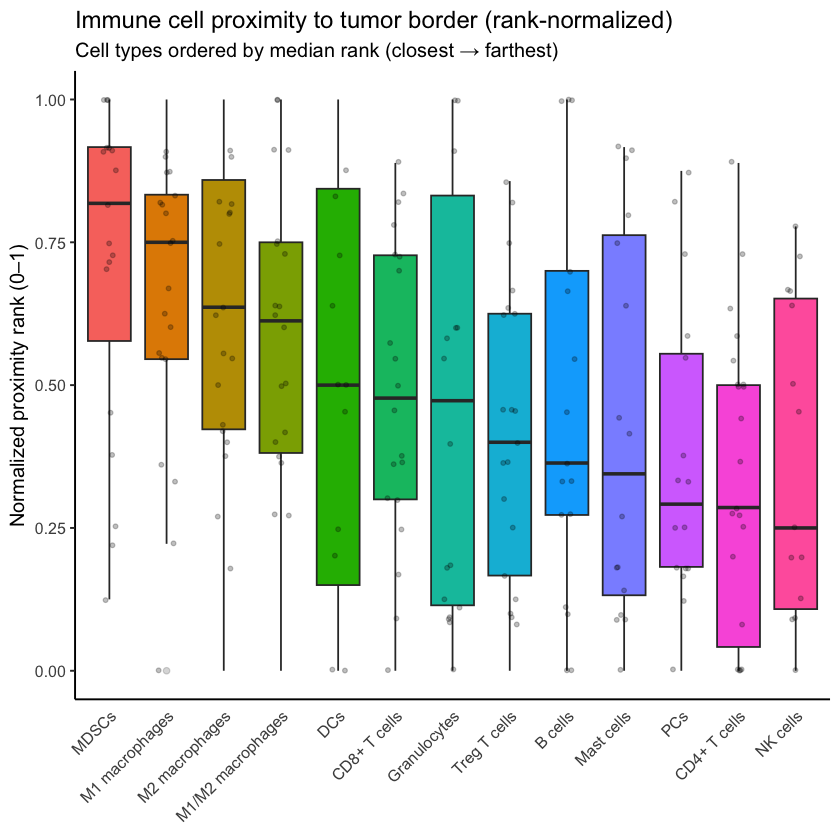

In [114]:

# all_res must have: cell_type, rank01
dt <- copy(all_res)

# Order cell types by median rank01 (high -> low)
ord <- dt[, .(med = median(rank01, na.rm=TRUE)), by=cell_type][order(-med)]
dt[, cell_type := factor(cell_type, levels = ord$cell_type)]

ggplot(dt, aes(x = cell_type, y = rank01, fill = cell_type)) +
  geom_boxplot(width = 0.75, outlier.alpha = 0.2) +
  # optional: show per-ROI points lightly
  geom_jitter(width = 0.15, alpha = 0.25, size = 1) +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25)) +
  guides(fill = "none") +  # hide legend (too many cell types)
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.ticks.x = element_blank()
  ) +
  labs(
    x = NULL,
    y = "Normalized proximity rank (0–1)",
    title = "Immune cell proximity to tumor border (rank-normalized)",
    subtitle = "Cell types ordered by median rank (closest → farthest)"
  )


In [115]:
all_res

roi,cell_type,n,beta1,proximity,rank,rank01
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
NMC_1_ROI3,MDSCs,113,0.012187475,-0.012187475,2,0.1250000
NMC_1_ROI3,M1/M2 macrophages,128,-0.105973636,0.105973636,9,1.0000000
NMC_1_ROI3,Treg T cells,42,0.016240922,-0.016240922,1,0.0000000
NMC_1_ROI3,M2 macrophages,205,-0.017390836,0.017390836,6,0.6250000
NMC_1_ROI3,M1 macrophages,164,-0.042363421,0.042363421,7,0.7500000
NMC_1_ROI3,CD4+ T cells,66,-0.015851058,0.015851058,5,0.5000000
NMC_1_ROI3,NK cells,45,0.009365940,-0.009365940,3,0.2500000
NMC_1_ROI3,CD8+ T cells,45,0.005224014,-0.005224014,4,0.3750000
NMC_1_ROI3,PCs,19,-0.095935189,0.095935189,8,0.8750000


In [121]:
library(circlize)
library(ComplexHeatmap)

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))


Loading required package: grid


Attaching package: ‘grid’


The following object is masked from ‘package:spatstat.geom’:

    as.mask


ComplexHeatmap version 2.23.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinfo

In [127]:
# ----------------------------------------------------
# 3) Build the matrix (rows=cell types, cols=samples)
#    Use zscore (or switch to `Tumor cells` if desired)
# ----------------------------------------------------
mat <- all_res %>%
  select(roi, cell_type, rank01) %>%
  pivot_wider(names_from = roi, values_from = rank01) %>%
  arrange(cell_type)

mat_rownames <- mat$cell_type
mat <- as.matrix(mat[, -1, drop = FALSE])
rownames(mat) <- mat_rownames

# -----------------------------
# 5) Color scheme (purple->white)
# -----------------------------
col_fun <- circlize::colorRamp2(
  c(0, 0.5, 1),
  c("#FFFFFF", "#D9A6E5", "#6A00A8")
)

myeloid <- c("MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
             "Granulocytes", "Mast cells", "DCs")
lymphoid <- c("CD8+ T cells", "CD4+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")

desired_order <- c(myeloid, lymphoid)
# Keep only cell types that exist in mat
desired_order <- desired_order[desired_order %in% rownames(mat)]

# Reorder matrix
mat <- mat[desired_order, , drop = FALSE]


# Row split vector in the same order as the matrix rows
row_split_vec <- ifelse(rownames(mat) %in% myeloid, "Lymphoid", "Myeloid")



# -----------------------------
# 6) Draw heatmap
# -----------------------------
svglite::svglite(filename = "~/Desktop/heatmap_output_distance.svg", width = 12, height = 8)


ht <- ComplexHeatmap::Heatmap(
  mat,
  name = "Scaled distance",
  col = col_fun,
  na_col = "grey85",
  column_title = "Average Euclidean distance to Tumor cells by sample",
  row_title = NULL,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 45,
  row_split = row_split_vec,      # Myeloid vs Lymphoid split
  row_gap = unit(2, "mm"),         # visual separator between splits
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  heatmap_legend_param = list(
    title = "Scaled distance",
    at = c(0, 0.5, 1)
  ),
 row_names_side = "left",
 column_names_gp = gpar(fontsize = 8),
 row_names_gp = gpar(fontsize = 8),
 column_title_gp = gpar(fontsize = 11, fontface = "bold"),
 row_title_gp = gpar(fontsize = 11, fontface = "bold")
)

draw(ht)

dev.off()


pdf 
  2

In [8]:
#spatial interaction all cell types

results_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/"
interaction <- read_csv(file.path(results_dir, "spatial_interaction_all_cell_types.csv"), show_col_types = FALSE)
excluded_cells <- c("NFC", "Epithelial cells", "Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells")
interaction <- interaction %>%
  filter(!cell_category %in% excluded_cells) %>%
  filter(!neighbour_cell_category %in% excluded_cells) %>%
  mutate(
    patient_number = as.numeric(str_extract(patient_exp, "(?<=_)\\d+(?=_)")),
    roi_number = as.numeric(str_extract(patient_exp, "\\d+$"))
  ) %>%
  arrange(patient_number, roi_number) %>%
  select(-c(patient_number, roi_number)) %>%
  mutate(patient_ID = str_extract(patient_exp, "^[^_]+_[^_]+")) 
interaction

cell_category,neighbour_cell_category,patient_exp,zscore,patient_ID
<chr>,<chr>,<chr>,<dbl>,<chr>
B cells,B cells,NMC_1_ROI1,2.21390234,NMC_1
B cells,CD4+ T cells,NMC_1_ROI1,-1.28370577,NMC_1
B cells,CD8+ T cells,NMC_1_ROI1,1.42777225,NMC_1
B cells,DCs,NMC_1_ROI1,-0.15430862,NMC_1
B cells,Granulocytes,NMC_1_ROI1,-0.30752920,NMC_1
B cells,M1 macrophages,NMC_1_ROI1,-2.40942420,NMC_1
B cells,M1/M2 macrophages,NMC_1_ROI1,-0.40926401,NMC_1
B cells,M2 macrophages,NMC_1_ROI1,-1.13744779,NMC_1
B cells,MDSCs,NMC_1_ROI1,-1.50749410,NMC_1


In [21]:
interaction_test <- interaction %>%
filter(!patient_exp %in% c('NMC_12_ROI6', 'NMC_21_ROI')) %>%
filter((cell_category != "Tumor cells" & neighbour_cell_category == "Tumor cells")) %>%
mutate(cell_pair = paste0(cell_category, "-", neighbour_cell_category)) %>%
arrange(cell_pair) %>%
group_by(patient_ID, cell_pair) %>% 
summarise(zscore_median = median(zscore, na.rm=TRUE)) %>%
ungroup()

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_pair.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_pair))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [26]:
mat <- interaction_test %>%
  select(patient_ID, cell_pair, zscore_median) %>%
  pivot_wider(names_from = patient_ID, values_from = zscore_median)

mat_rownames <- mat$cell_pair
mat <- as.matrix(mat[, -1, drop = FALSE])
rownames(mat) <- mat_rownames

# -----------------------------
# 5) Color scheme (purple->white)
# -----------------------------
col_fun <- circlize::colorRamp2(
  c(-10, 0, 10),
  c("blue", "white", "red")
)

# myeloid <- c("MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
#              "Granulocytes", "Mast cells", "DCs")
# lymphoid <- c("CD8+ T cells", "CD4+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")

# desired_order <- c(myeloid, lymphoid)
# # Keep only cell types that exist in mat
# desired_order <- desired_order[desired_order %in% rownames(mat)]

# # Reorder matrix
# mat <- mat[desired_order, , drop = FALSE]


# # Row split vector in the same order as the matrix rows
# row_split_vec <- ifelse(rownames(mat) %in% myeloid, "Lymphoid", "Myeloid")


# -----------------------------
# 6) Draw heatmap
# -----------------------------
svglite::svglite(filename = "~/Desktop/heatmap_test.svg", width = 12, height = 12)


ht <- ComplexHeatmap::Heatmap(
  mat,
  name = "z score",
  col = col_fun,
  na_col = "grey85",
  column_title = "Interaction of immune cells to tumor cells",
  row_title = NULL,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 45,
  row_gap = unit(2, "mm"),         # visual separator between splits
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  heatmap_legend_param = list(
    title = "z score",
    at = c(-10, 0, 10)
  ),
 row_names_side = "left",
 column_names_gp = gpar(fontsize = 8),
 row_names_gp = gpar(fontsize = 8),
 column_title_gp = gpar(fontsize = 11, fontface = "bold"),
 row_title_gp = gpar(fontsize = 11, fontface = "bold")
)

draw(ht)

dev.off()


agg_record_1655720223 
                    2

In [42]:
#filter for MDSCs-tumor interaction, M2 macrophages, and granulocytes....
interaction_selected = interaction %>%
filter(neighbour_cell_category == "Tumor cells" & !cell_category %in% c("Tumor cells")) %>%
filter(cell_category %in% c("MDSCs", "M2 macrophages", "Granulocytes"))

95% 
25.54484

In [45]:
mat <- interaction_selected %>%
  select(patient_exp, cell_category, zscore) %>%
  pivot_wider(names_from = patient_exp, values_from = zscore) %>%
  arrange(cell_category)
  
mat_rownames <- mat$cell_category
mat <- as.matrix(mat[, -1, drop = FALSE])
rownames(mat) <- mat_rownames

col_fun <- circlize::colorRamp2(
  c(-10, 0, 10),
  c("blue","white", "red")
)

row_split_vec <- ifelse(rownames(mat) %in% myeloid, "Lymphoid", "Myeloid")

svglite::svglite(filename = "~/Desktop/testing_heatmap.svg", width = 12, height = 8)

ht <- ComplexHeatmap::Heatmap(
  mat,
  col = col_fun,
  name = "z_score",
  na_col = "grey85",
  column_title = "Interaction score to tumor cells",
  row_title = NULL,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 45,
  row_gap = unit(2, "mm"),         # visual separator between splits
  cluster_rows = FALSE,
  cluster_columns = TRUE,
 row_names_side = "left",
 column_names_gp = gpar(fontsize = 8),
 row_names_gp = gpar(fontsize = 8),
 column_title_gp = gpar(fontsize = 11, fontface = "bold"),
 row_title_gp = gpar(fontsize = 11, fontface = "bold")
)


draw(ht)

dev.off()


agg_record_940553841 
                   2

In [57]:
# ----------------------------------------------------
# 3) Build the matrix (rows=cell types, cols=samples)
#    Use zscore (or switch to `Tumor cells` if desired)
# ----------------------------------------------------
mat <- interaction_selected %>%
  select(patient_exp, cell_category, zscore) %>%
  pivot_wider(names_from = patient_exp, values_from = zscore)

mat_rownames <- mat$cell_category
mat <- as.matrix(mat[, -1, drop = FALSE])
rownames(mat) <- mat_rownames

# -----------------------------
# 5) Color scheme (purple->white)
# -----------------------------
col_fun <- circlize::colorRamp2(
  c(-30, 0, 30),
  c("blue", "white", "red")
)

# myeloid <- c("MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
#              "Granulocytes", "Mast cells", "DCs")
# lymphoid <- c("CD8+ T cells", "CD4+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")

# desired_order <- c(myeloid, lymphoid)
# # Keep only cell types that exist in mat
# desired_order <- desired_order[desired_order %in% rownames(mat)]

# # Reorder matrix
# mat <- mat[desired_order, , drop = FALSE]


# # Row split vector in the same order as the matrix rows
# row_split_vec <- ifelse(rownames(mat) %in% myeloid, "Lymphoid", "Myeloid")


# -----------------------------
# 6) Draw heatmap
# -----------------------------
svglite::svglite(filename = "~/Desktop/heatmap_test.svg", width = 12, height = 8)


ht <- ComplexHeatmap::Heatmap(
  mat,
  name = "z score",
  col = col_fun,
  na_col = "grey85",
  column_title = "Interaction of immune cells to tumor cells",
  row_title = NULL,
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_names_rot = 45,
  row_gap = unit(2, "mm"),         # visual separator between splits
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  heatmap_legend_param = list(
    title = "z score",
    at = c(-30, 0, 30)
  ),
 row_names_side = "left",
 column_names_gp = gpar(fontsize = 8),
 row_names_gp = gpar(fontsize = 8),
 column_title_gp = gpar(fontsize = 11, fontface = "bold"),
 row_title_gp = gpar(fontsize = 11, fontface = "bold")
)

draw(ht)

dev.off()


agg_record_1946336692 
                    2

In [27]:
kontextual_df <- celltype_metadata %>%
    rename("cellType" = "cell_category",
           "imageID" = "patient_exp",
           "x" = "Cell Center X",
           "y" = "Cell Center Y") %>%
    select(imageID, cellType, x, y) %>%
    mutate(x = x * 0.17,
           y = y * 0.17) 
kontextual_df

imageID,cellType,x,y
<chr>,<chr>,<dbl>,<dbl>
NMC_1_ROI3,M1/M2 macrophages,1807.34006,351.8573
NMC_1_ROI3,NFC,1503.68503,463.1979
NMC_1_ROI3,Tumor cells,1312.98504,464.7060
NMC_1_ROI3,Tumor cells,714.46094,466.7154
NMC_1_ROI3,Tumor cells,40.22877,464.2813
NMC_1_ROI3,NFC,1487.03184,464.6895
NMC_1_ROI3,Tumor cells,1300.29447,463.2326
NMC_1_ROI3,Tumor cells,1158.58868,464.7077
NMC_1_ROI3,Tumor cells,400.36917,464.9147


In [28]:
#create cell groups
tcells <- c("CD8+ T cells", "CD4+ T cells", "Treg T cells")
bcells <- c("B cells", "PCs")
macrophages <- c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages")
lymphoid <- c(tcells, bcells, "NK cells")
myeloid <- c(macrophages, "MDSCs", "Granulocytes", "Mast cells", "DCs")
immune <- c(lymphoid, myeloid)
tissue <- c("NFC", "Actin+ cells", "Epithelial cells", "Endothelial cells", "Lymphatic endothelial cells")
tumor <- "Tumor cells"
all <- list(tcells, bcells, macrophages, lymphoid, myeloid, immune, tissue, tumor)

In [37]:
biologicalHierarchy = list(
  "tumour" = "Tumor cells",
  "lymphoid" = c("CD4+ T cells","CD8+ T cells", "Treg T cells", "B cells", "PCs", "NK cells"),
  "myeloid" = c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "MDSCs", "Granulocytes", "Mast cells", "DCs"),
  "immune" = c("CD4+ T cells","CD8+ T cells", "Treg T cells", "B cells", "PCs", "NK cells",
              "M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "MDSCs", "Granulocytes", "Mast cells", "DCs"),
  "tissue" = c("NFC", "Actin+ cells", "Epithelial cells", "Endothelial cells", "Lymphatic endothelial cells")
)

In [38]:
parentDf <- parentCombinations(
  all = unique(celltype_metadata$cell_category),
  parentList = biologicalHierarchy
)
parentDf

from,to,parent,parent_name
<chr>,<chr>,<I<list>>,<chr>
M1/M2 macrophages,B cells,CD4+ T c....,immune
NFC,B cells,CD4+ T c....,immune
Tumor cells,B cells,CD4+ T c....,immune
MDSCs,B cells,CD4+ T c....,immune
M2 macrophages,B cells,CD4+ T c....,immune
Actin+ cells,B cells,CD4+ T c....,immune
Treg T cells,B cells,CD4+ T c....,immune
CD4+ T cells,B cells,CD4+ T c....,immune
M1 macrophages,B cells,CD4+ T c....,immune


In [39]:
kontextual_results_all <- Kontextual(
  cells = kontextual_df,
  parentDf = parentDf,
  r = 100,
  cores = 1
)

In [1]:
kontextual

ERROR: Error: object 'kontextual' not found


In [30]:
kontextual_results <- Kontextual(
  cells = kontextual_df,
  r = 100,
  from = "MDSCs",
  to = "CD8+ T cells",
  parent = immune,
  cellType = "cellType"
)
kontextual_results

imageID,test,original,kontextual,r,inhomL
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>
NMC_1_ROI1,MDSCs__CD8+ T cells,38.325076,11.352640,100,FALSE
NMC_1_ROI3,MDSCs__CD8+ T cells,7.075838,2.776275,100,FALSE
NMC_12_ROI5,MDSCs__CD8+ T cells,-54.147807,-45.925849,100,FALSE
NMC_13_ROI14,MDSCs__CD8+ T cells,-5.274439,-2.708840,100,FALSE
NMC_13_ROI15,MDSCs__CD8+ T cells,-32.921355,-16.361531,100,FALSE
NMC_14_ROI11,MDSCs__CD8+ T cells,-14.574443,-22.868135,100,FALSE
NMC_14_ROI8,MDSCs__CD8+ T cells,57.262935,-4.374832,100,FALSE
NMC_15_ROI16,MDSCs__CD8+ T cells,3.706193,-14.736828,100,FALSE
NMC_15_ROI7,MDSCs__CD8+ T cells,14.836974,1.975819,100,FALSE


In [38]:
  curves <- kontextCurve(
  cells = kontextual_df,
  from = "Granulocytes",
  to = "Tumor cells",
  parent = immune,
  rs = seq(50, 250, 50),
  image = "NMC_9_ROI4",
  cellType = "cellType")

Ignoring unknown labels:
• fill : "Function"


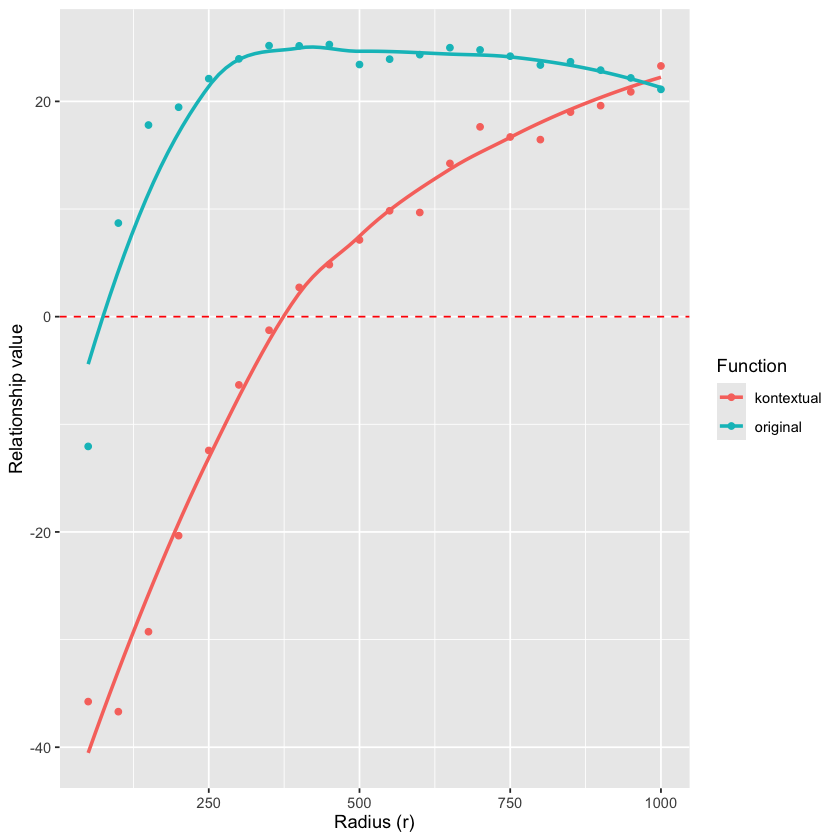

In [23]:
kontextPlot(curves)

[1] "CD8+ T cells" "CD4+ T cells" "Treg T cells" "B cells"      "PCs"         
[6] "NK cells"

In [101]:
#read distances from cells df
distances <- read_csv(file.path(results_dir, "cell_distance_to_tumor_contour.csv"), show_col_types = FALSE) %>%
    select(!...1) %>%
    mutate(cell_group = case_when(
        cell_category %in% myeloid ~ "Myeloid",
        cell_category %in% lymphoid ~ "Lymphoid",
        cell_category == "Tumor cells" ~ "Tumor",
        TRUE ~ "Non-immune"
    ))

averaged_distances <- distances %>%
    filter(tumor_signed_dist_to_contour_um >= 0) %>%
    group_by(patient_exp, cell_group) %>%
    summarise(avg_distance = median(tumor_dist_to_contour_um)) %>%
    filter(!cell_group %in% c("Tumor", "Non-immune"))

averaged_distances_pivot <- averaged_distances %>%
    pivot_wider(names_from = cell_group, values_from = avg_distance)

test <- wilcox.test(
  averaged_distances_pivot$Myeloid,
  averaged_distances_pivot$Lymphoid,
  paired = TRUE,
  alternative = "two.sided"
)

pval_label <- paste0("p = ", signif(test$p.value, 3))

plot_df <- averaged_distances_pivot %>%
  select(patient_exp, Myeloid, Lymphoid) %>%
  drop_na(Myeloid, Lymphoid) %>%
  pivot_longer(cols = c(Myeloid, Lymphoid),
               names_to = "cell_group",
               values_to = "median_distance_um")



New names:
• `` -> `...1`
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_exp and cell_group.
ℹ Output is grouped by patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_exp, cell_group))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
Warning message in wilcox.test.default(averaged_distances_pivot$Myeloid, averaged_distances_pivot$Lymphoid, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(averaged_distances_pivot$Myeloid, averaged_distances_pivot$Lymphoid, :
“cannot compute exact p-value with zeroes”


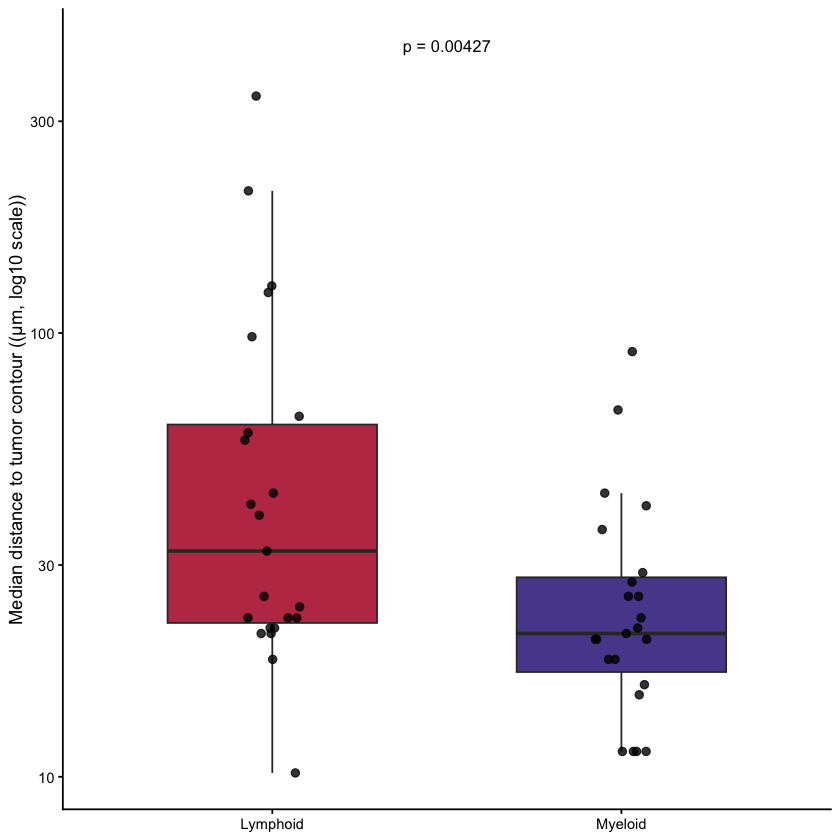

In [103]:
cell_colors <- c(
  "Lymphoid" = "#B2182B",
  "Myeloid"  = "#332288"
)

ggplot(plot_df, aes(x = cell_group, y = median_distance_um, fill = cell_group)) +
  geom_boxplot(
    outlier.shape = NA,
    width = 0.6,
    alpha = 0.85
  ) +
  geom_point(
    position = position_jitter(width = 0.08, height = 0),
    size = 2,
    alpha = 0.8,
    color = "black"
  ) +
  scale_fill_manual(values = cell_colors) +
  scale_y_log10() +
  annotate(
    "text",
    x = 1.5,
    y = max(plot_df$median_distance_um, na.rm = TRUE) * 1.3,
    label = pval_label,
    size = 3.5
  ) +
  labs(
    x = NULL,
    y = "Median distance to tumor contour ((µm, log10 scale))"
  ) +
  theme_classic() +
  theme(
    legend.position = "none"
  )


In [147]:
# 1) one row per ROI × category
cat_distances <- distances %>%
  filter(tumor_signed_dist_to_contour_um >= 0) %>%
  group_by(patient_exp, cell_category) %>%
  summarise(median_distance_um = median(tumor_dist_to_contour_um), .groups = "drop") %>%
filter(cell_category %in% c(myeloid, lymphoid))

# 2) wide table (ROI as rows, categories as columns)
cat_wide <- cat_distances %>%
  pivot_wider(names_from = cell_category, values_from = median_distance_um)

order_cats <- cat_distances %>%
  group_by(cell_category) %>%
  summarise(
    med = median(median_distance_um, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(med) %>%   # <-- decreasing order
  pull(cell_category)

cat_distances$cell_category <- factor(
  cat_distances$cell_category,
  levels = order_cats
)

# 3) pairwise paired wilcox, aligned by ROI (complete.cases per pair)
cats <- setdiff(names(cat_wide), "patient_exp")
pairs <- combn(cats, 2, simplify = FALSE)

pw <- map_dfr(pairs, \(p) {
  g1 <- p[1]; g2 <- p[2]
  sub <- cat_wide %>% select(patient_exp, all_of(c(g1, g2))) %>% drop_na()

  n_pairs <- nrow(sub)
  if (n_pairs < 3) {
    return(tibble::tibble(group1 = g1, group2 = g2, n = n_pairs, p_value = NA_real_))
  }

  tt <- wilcox.test(sub[[g1]], sub[[g2]], paired = TRUE, exact = FALSE)
  tibble::tibble(group1 = g1, group2 = g2, n = n_pairs, p_value = tt$p.value)
}) %>%
  mutate(p_adj = p.adjust(p_value, method = "BH")) %>%
  arrange(p_adj)

pw_sig <- pw %>% filter(!is.na(p_adj), p_adj < 0.05)
pw_sig



group1,group2,n,p_value,p_adj
<chr>,<chr>,<int>,<dbl>,<dbl>
CD4+ T cells,M1 macrophages,23,0.0006223500,0.01920027
CD4+ T cells,M2 macrophages,23,0.0006957022,0.01920027
CD4+ T cells,MDSCs,20,0.0011974130,0.01920027
M2 macrophages,PCs,18,0.0014769440,0.01920027
MDSCs,PCs,16,0.0012301396,0.01920027
MDSCs,Treg T cells,20,0.0014131909,0.01920027
CD8+ T cells,MDSCs,20,0.0030621988,0.02197067
M1 macrophages,PCs,18,0.0030621988,0.02197067
M2 macrophages,NK cells,22,0.0022749549,0.02197067


In [148]:
myeloid_lymphoid_colors <- c(
  # ---- Lymphoid ----
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#7F1D1D",
  "NK cells"     = "#6E8B8F",
  "B cells"      = "#F0D34F",
  "PCs"          = "#B88A00",

  # ---- Myeloid ----
  "M1 macrophages"    = "#E16A2E",
  "M2 macrophages"    = "#6F8F1A",
  "M1/M2 macrophages" = "#F6AE2D",
  "DCs"               = "#D4A72C",
  "Granulocytes"      = "#7B61B3",
  "MDSCs"             = "#0077A8",
  "Mast cells"        = "#5A3B2E"
)


In [134]:
if (nrow(pw_sig) > 0) {
  y_top <- max(cat_distances$median_distance_um, na.rm = TRUE)

  pw_sig <- pw_sig %>%
    arrange(p_adj) %>%
    mutate(y.position = y_top * (1.15 + 0.08 * row_number()))
}

In [142]:
# keep only significant comparisons (if not already done)
pw_sig <- pw %>%
  filter(!is.na(p_adj), p_adj < 0.05) %>%
  arrange(p_adj)

# add star labels (or switch to numeric if you prefer)
pw_sig <- pw_sig %>%
  mutate(
    p.adj.signif = case_when(
      p_adj <= 0.001 ~ "***",
      p_adj <= 0.01  ~ "**",
      p_adj <= 0.05  ~ "*",
      TRUE ~ "ns"
    )
  )

# add y positions stacked above the data
y_top <- max(cat_distances$median_distance_um, na.rm = TRUE)

pw_sig <- pw_sig %>%
  mutate(y.position = y_top * (1.15 + 0.10 * row_number()))

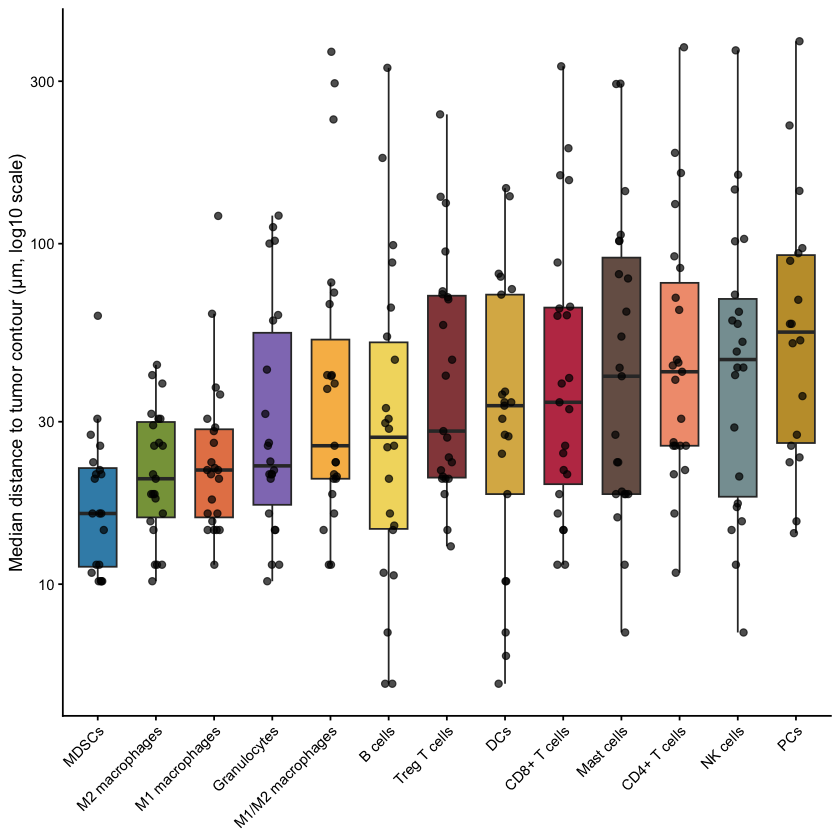

In [149]:
p <- ggplot(
  cat_distances,
  aes(x = cell_category, y = median_distance_um, fill = cell_category)
) +
  geom_boxplot(
    outlier.shape = NA,
    width = 0.65,
    alpha = 0.85
  ) +
  geom_point(
    position = position_jitter(width = 0.12),
    size = 1.7,
    alpha = 0.7,
    color = "black"
  ) +
  scale_fill_manual(values = myeloid_lymphoid_colors, drop = FALSE) +
  scale_y_log10() +
  labs(
    x = NULL,
    y = "Median distance to tumor contour (µm, log10 scale)"
  ) +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
  )


p

In [152]:
# ============================================================
# Structural proximity to tumor contour via Poisson point process (spatstat)
# - Fits ppm(X ~ D_im) per ROI × (cell_category or cell_group)
# - Proximity score: proximity = -beta1  (beta1 < 0 => enrichment near contour)
# - Optional permutation null by resampling locations from the immune pool
# ============================================================

# ----------------------------
# Utilities
# ----------------------------

stouffer_p <- function(pvals) {
  pvals <- pvals[is.finite(pvals) & !is.na(pvals)]
  if (length(pvals) == 0) return(NA_real_)
  z <- qnorm(1 - pvals)          # one-sided
  Z <- sum(z) / sqrt(length(z))
  1 - pnorm(Z)
}

make_win_and_covariate <- function(results_dir, roi_tag, scale_dist = 100) {
  meta <- fromJSON(file.path(results_dir, paste0(roi_tag, "_meta.json")))
  D_out <- np$load(file.path(results_dir, paste0(roi_tag, "_dist_out.npy")))

  xrange <- c(meta$x_min, meta$x_min + (meta$nx - 1) * meta$grid_size)
  yrange <- c(meta$y_min, meta$y_min + (meta$ny - 1) * meta$grid_size)

  Win <- owin(xrange = xrange, yrange = yrange)

  D_mat <- as.matrix(D_out)
  if (!is.null(scale_dist) && scale_dist > 0) D_mat <- D_mat / scale_dist
  D_im <- as.im(D_mat, W = Win)

  list(Win = Win, D_im = D_im)
}

# Keep cells in ROI bbox, outside tumor, and optionally immune-only
filter_cells <- function(cells,
                         roi_tag,
                         Win,
                         roi_col = "patient_exp",
                         x_col = "Cell Center X",
                         y_col = "Cell Center Y",
                         cell_col = "cell_category",
                         tumor_label = "Tumor cells",
                         outside_only = TRUE,
                         immune_only = TRUE) {

  stopifnot(is.data.table(cells))

  cf <- cells[get(roi_col) == roi_tag]

  if (nrow(cf) == 0) return(cf)

  # inside ROI window
  inside <- inside.owin(cf[[x_col]], cf[[y_col]], Win)
  cf <- cf[inside == TRUE]

  # outside tumor (choose whichever column exists)
  if (outside_only) {
    if ("tumor_territory" %in% names(cf)) {
      cf <- cf[tumor_territory == FALSE]
    } else if ("tumor_signed_dist_to_contour_um" %in% names(cf)) {
      cf <- cf[tumor_signed_dist_to_contour_um > 0]
    } else if ("tumor_signed_dist_to_contour" %in% names(cf)) {
      cf <- cf[tumor_signed_dist_to_contour > 0]
    } else {
      stop("Need tumor_territory or tumor_signed_dist_to_contour[_um] in cells.")
    }
  }

  # immune only (exclude tumor cells)
  if (immune_only) {
    cf <- cf[get(cell_col) != tumor_label]
  }

  cf[]
}

# Fit ppm and extract beta1 (distance effect)
fit_ppm_beta1 <- function(x, y, Win, D_im) {
  X <- ppp(x, y, window = Win)
  fit <- ppm(X ~ D_im)
  beta <- coef(fit)
  beta1 <- unname(beta[["D_im"]])  # more robust than index [2]
  list(beta1 = beta1, proximity = -beta1)
}

# Permutation null by resampling n points from the ROI immune pool locations
permute_proximity <- function(n,
                              Win,
                              D_im,
                              pool_x,
                              pool_y,
                              n_perm = 100,
                              seed = NULL) {
  if (!is.null(seed)) set.seed(seed)
  Npool <- length(pool_x)
  if (Npool < n) stop("Pool smaller than target sample size; cannot sample without replacement.")

  prox_perm <- numeric(n_perm)

  for (k in seq_len(n_perm)) {
    idx <- sample.int(Npool, size = n, replace = FALSE)
    fitk <- fit_ppm_beta1(pool_x[idx], pool_y[idx], Win, D_im)
    prox_perm[k] <- fitk$proximity
  }

  prox_perm
}

# ----------------------------
# ROI runner
# ----------------------------

run_one_roi_ppm <- function(results_dir,
                            roi_tag,
                            cells,
                            level = c("cell_category", "cell_group"),
                            myeloid = NULL,
                            lymphoid = NULL,
                            min_cells = 10,
                            scale_dist = 100,
                            do_perm = FALSE,
                            n_perm = 100,
                            roi_col = "patient_exp",
                            x_col = "Cell Center X",
                            y_col = "Cell Center Y",
                            cell_col = "cell_category",
                            tumor_label = "Tumor cells") {

  level <- match.arg(level)
  stopifnot(is.data.table(cells))

  wd <- make_win_and_covariate(results_dir, roi_tag, scale_dist = scale_dist)
  Win <- wd$Win
  D_im <- wd$D_im

  cf <- filter_cells(
    cells, roi_tag, Win,
    roi_col = roi_col, x_col = x_col, y_col = y_col,
    cell_col = cell_col, tumor_label = tumor_label,
    outside_only = TRUE, immune_only = TRUE
  )
  if (nrow(cf) == 0) return(data.table())

  # Define analysis label (cell_category or cell_group)
  if (level == "cell_group") {
    if (is.null(myeloid) || is.null(lymphoid)) stop("Provide myeloid and lymphoid vectors for level='cell_group'.")
    cf[, cell_group := fifelse(get(cell_col) %in% myeloid, "Myeloid",
                        fifelse(get(cell_col) %in% lymphoid, "Lymphoid", NA_character_))]
    cf <- cf[!is.na(cell_group)]
    type_col <- "cell_group"
  } else {
    type_col <- cell_col
  }

  if (nrow(cf) == 0) return(data.table())

  # pool = all immune outside-tumor coords in this ROI (for permutation null)
  pool_x <- cf[[x_col]]
  pool_y <- cf[[y_col]]

  out <- rbindlist(lapply(unique(cf[[type_col]]), function(ct) {
    pts <- cf[get(type_col) == ct]
    n <- nrow(pts)
    if (n < min_cells) return(NULL)

    obs <- fit_ppm_beta1(pts[[x_col]], pts[[y_col]], Win, D_im)

    if (do_perm) {
      prox_perm <- permute_proximity(
        n = n, Win = Win, D_im = D_im,
        pool_x = pool_x, pool_y = pool_y,
        n_perm = n_perm
      )
      # one-sided p-value: how often permuted is >= observed (at least as proximal)
      pval <- (sum(prox_perm >= obs$proximity) + 1) / (n_perm + 1)
    } else {
      pval <- NA_real_
    }

    data.table(
      roi = roi_tag,
      level = level,
      cell_type = ct,
      n = n,
      beta1 = obs$beta1,          # beta1 < 0 => enriched near structure
      proximity = obs$proximity,  # larger => more proximal
      pval = pval
    )
  }), fill = TRUE)

  if (nrow(out) == 0) return(out)

  # within-ROI normalized rank (0..1) of proximity across types present in this ROI
  out[, rank := frank(proximity, ties.method = "average")]
  out[, rank01 := if (max(rank) > 1) (rank - 1) / (max(rank) - 1) else 0.5]
  out[]
}

# ----------------------------
# Run all ROIs + aggregate
# ----------------------------

run_all_rois_ppm <- function(results_dir,
                             cells,
                             roi_tags = unique(cells$patient_exp),
                             level = c("cell_category", "cell_group"),
                             myeloid = NULL,
                             lymphoid = NULL,
                             min_cells = 10,
                             scale_dist = 100,
                             do_perm = FALSE,
                             n_perm = 100,
                             min_rois_per_type = 6) {

  level <- match.arg(level)
  stopifnot(is.data.table(cells))

  all_res <- rbindlist(lapply(roi_tags, function(tag) {
    message("ROI: ", tag)
    run_one_roi_ppm(
      results_dir = results_dir,
      roi_tag = tag,
      cells = cells,
      level = level,
      myeloid = myeloid,
      lymphoid = lymphoid,
      min_cells = min_cells,
      scale_dist = scale_dist,
      do_perm = do_perm,
      n_perm = n_perm
    )
  }), fill = TRUE)

  if (nrow(all_res) == 0) return(list(all_res = all_res, agg = data.table()))

  agg <- all_res[, .(
    n_rois = uniqueN(roi),
    n_cells_total = sum(n),
    median_proximity = median(proximity, na.rm = TRUE),
    median_rank01 = median(rank01, na.rm = TRUE),
    stouffer_p = if (do_perm) stouffer_p(pval) else NA_real_
  ), by = .(level, cell_type)][order(-median_rank01)]

  agg <- agg[n_rois >= min_rois_per_type]

  list(all_res = all_res, agg = agg)
}

# ============================================================
# Example usage
# ============================================================

# Inputs
results_dir <- "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/ppm/"
cells_all <- fread("/Users/jawadalaaedeen/Desktop/cells_df.csv")

# (Optional) define myeloid/lymphoid category lists for cell_group
# myeloid <- c("M1 macrophages", "M2 macrophages", "MDSCs", ...)
# lymphoid <- c("CD8+ T cells", "CD4+ T cells", "B cells", ...)

# --- Run PPP validation at cell_group level (recommended main validation) ---
# res_group <- run_all_rois_ppm(
#   results_dir = results_dir,
#   cells = cells_all,
#   level = "cell_group",
#   myeloid = myeloid,
#   lymphoid = lymphoid,
#   min_cells = 10,
#   do_perm = TRUE,
#   n_perm = 100,
#   min_rois_per_type = 6
# )
# fwrite(res_group$all_res, file.path(results_dir, "ppm_roi_level_cell_group.csv"))
# fwrite(res_group$agg,     file.path(results_dir, "ppm_aggregate_cell_group.csv"))

# --- Run PPP validation at cell_category level (subtypes; usually supplement) ---
# res_cat <- run_all_rois_ppm(
#   results_dir = results_dir,
#   cells = cells_all,
#   level = "cell_category",
#   min_cells = 10,
#   do_perm = TRUE,
#   n_perm = 100,
#   min_rois_per_type = 6
# )
# fwrite(res_cat$all_res, file.path(results_dir, "ppm_roi_level_cell_category.csv"))
# fwrite(res_cat$agg,     file.path(results_dir, "ppm_aggregate_cell_category.csv"))


In [155]:
library(reticulate)

# Optionally point to a specific Python (pick ONE approach)
# use_python("/usr/local/bin/python3", required = TRUE)
# use_condaenv("your_env_name", required = TRUE)
# use_virtualenv("your_venv_name", required = TRUE)

np <- import("numpy", convert = TRUE)

In [159]:
#--- Run PPP validation at cell_category level (subtypes; usually supplement) ---
res_cat <- run_all_rois_ppm(
  results_dir = results_dir,
  cells = cells_all,
  level = "cell_category",
  min_cells = 10,
  do_perm = TRUE,
  n_perm = 100,
  min_rois_per_type = 6
)

ROI: NMC_1_ROI3

ROI: NMC_1_ROI1

ROI: NMC_2_ROI1

ROI: NMC_4_ROI9

ROI: NMC_5_ROI11

ROI: NMC_5_ROI10

ROI: NMC_6_ROI5

ROI: NMC_6_ROI6

ROI: NMC_7_ROI14

ROI: NMC_7_ROI13

ROI: NMC_8_ROI17

ROI: NMC_9_ROI3

ROI: NMC_9_ROI4

ROI: NMC_12_ROI5

ROI: NMC_13_ROI15

ROI: NMC_13_ROI14

ROI: NMC_14_ROI8

ROI: NMC_14_ROI11

ROI: NMC_15_ROI7

ROI: NMC_15_ROI16

ROI: NMC_16_ROI17

ROI: NMC_16_ROI19

ROI: NMC_21_ROI23



In [160]:
res_cat

roi,level,cell_type,n,beta1,proximity,pval,rank,rank01
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NMC_1_ROI3,cell_category,MDSCs,113,0.012187475,-0.012187475,1.00000000,2,0.1250000
NMC_1_ROI3,cell_category,M1/M2 macrophages,128,-0.105973636,0.105973636,0.00990099,9,1.0000000
NMC_1_ROI3,cell_category,Treg T cells,42,0.016240922,-0.016240922,0.94059406,1,0.0000000
NMC_1_ROI3,cell_category,M2 macrophages,205,-0.017390836,0.017390836,0.64356436,6,0.6250000
NMC_1_ROI3,cell_category,M1 macrophages,164,-0.042363421,0.042363421,0.05940594,7,0.7500000
NMC_1_ROI3,cell_category,CD4+ T cells,66,-0.015851058,0.015851058,0.54455446,5,0.5000000
NMC_1_ROI3,cell_category,NK cells,45,0.009365940,-0.009365940,0.92079208,3,0.2500000
NMC_1_ROI3,cell_category,CD8+ T cells,45,0.005224014,-0.005224014,0.85148515,4,0.3750000
NMC_1_ROI3,cell_category,PCs,19,-0.095935189,0.095935189,0.08910891,8,0.8750000


In [ ]:

# all_res must have: cell_type, rank01
dt <- copy(all_res)

# Order cell types by median rank01 (high -> low)
ord <- dt[, .(med = median(rank01, na.rm=TRUE)), by=cell_type][order(-med)]
dt[, cell_type := factor(cell_type, levels = ord$cell_type)]

ggplot(dt, aes(x = cell_type, y = rank01, fill = cell_type)) +
  geom_boxplot(width = 0.75, outlier.alpha = 0.2) +
  # optional: show per-ROI points lightly
  geom_jitter(width = 0.15, alpha = 0.25, size = 1) +
  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25)) +
  guides(fill = "none") +  # hide legend (too many cell types)
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    axis.ticks.x = element_blank()
  ) +
  labs(
    x = NULL,
    y = "Normalized proximity rank (0–1)",
    title = "Immune cell proximity to tumor border (rank-normalized)",
    subtitle = "Cell types ordered by median rank (closest → farthest)"
  )


In [167]:
res_cat

roi,level,cell_type,n,beta1,proximity,pval,rank,rank01
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NMC_1_ROI3,cell_category,MDSCs,113,0.012187475,-0.012187475,1.00000000,2,0.1250000
NMC_1_ROI3,cell_category,M1/M2 macrophages,128,-0.105973636,0.105973636,0.00990099,9,1.0000000
NMC_1_ROI3,cell_category,Treg T cells,42,0.016240922,-0.016240922,0.94059406,1,0.0000000
NMC_1_ROI3,cell_category,M2 macrophages,205,-0.017390836,0.017390836,0.64356436,6,0.6250000
NMC_1_ROI3,cell_category,M1 macrophages,164,-0.042363421,0.042363421,0.05940594,7,0.7500000
NMC_1_ROI3,cell_category,CD4+ T cells,66,-0.015851058,0.015851058,0.54455446,5,0.5000000
NMC_1_ROI3,cell_category,NK cells,45,0.009365940,-0.009365940,0.92079208,3,0.2500000
NMC_1_ROI3,cell_category,CD8+ T cells,45,0.005224014,-0.005224014,0.85148515,4,0.3750000
NMC_1_ROI3,cell_category,PCs,19,-0.095935189,0.095935189,0.08910891,8,0.8750000


In [176]:
# Order cell types by aggregate median_rank01
agg <- res_cat$agg
ord <- agg[order(median_rank01), cell_type]
res_cat$all_res[, cell_type := factor(cell_type, levels = ord)]

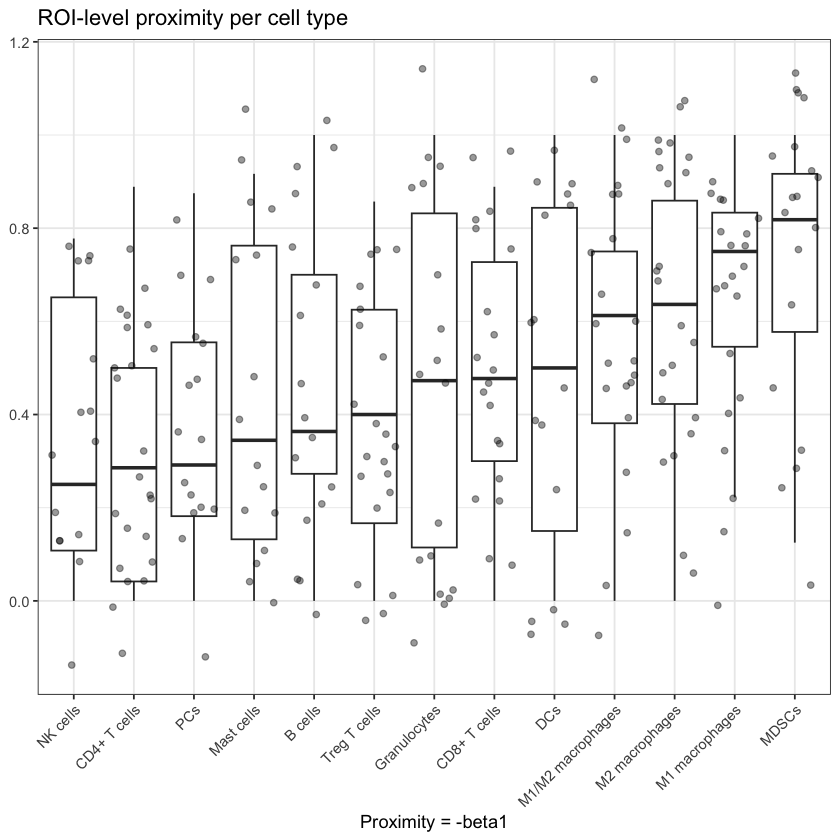

In [180]:
ggplot(res_cat$all_res, aes(rank01, cell_type)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.4) +
  coord_flip() +
  theme_bw() +
  labs(x=NULL, y="Proximity = -beta1", title="ROI-level proximity per cell type") +
  #make x-axis 45 degrees text
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
#A plot for content...
#Myeloid content of each sample
#make CD276 plot.... let's see what this brings...
